MULTI-MODEL MIGRATION ANALYSIS

Processing: BERT - lottery_ticket
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Successfully analyzed BERT - lottery_ticket

Processing: BERT - wanda
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Successfully analyzed BERT - wanda

Processing: BOWMAN - lottery_ticket
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Successfully analyzed BOWMAN - lottery_ticket

Processing: BOWMAN - wanda
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Successfully analyzed BOWMAN - wanda

Processing: LLAMA - lottery_ticket
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Succe

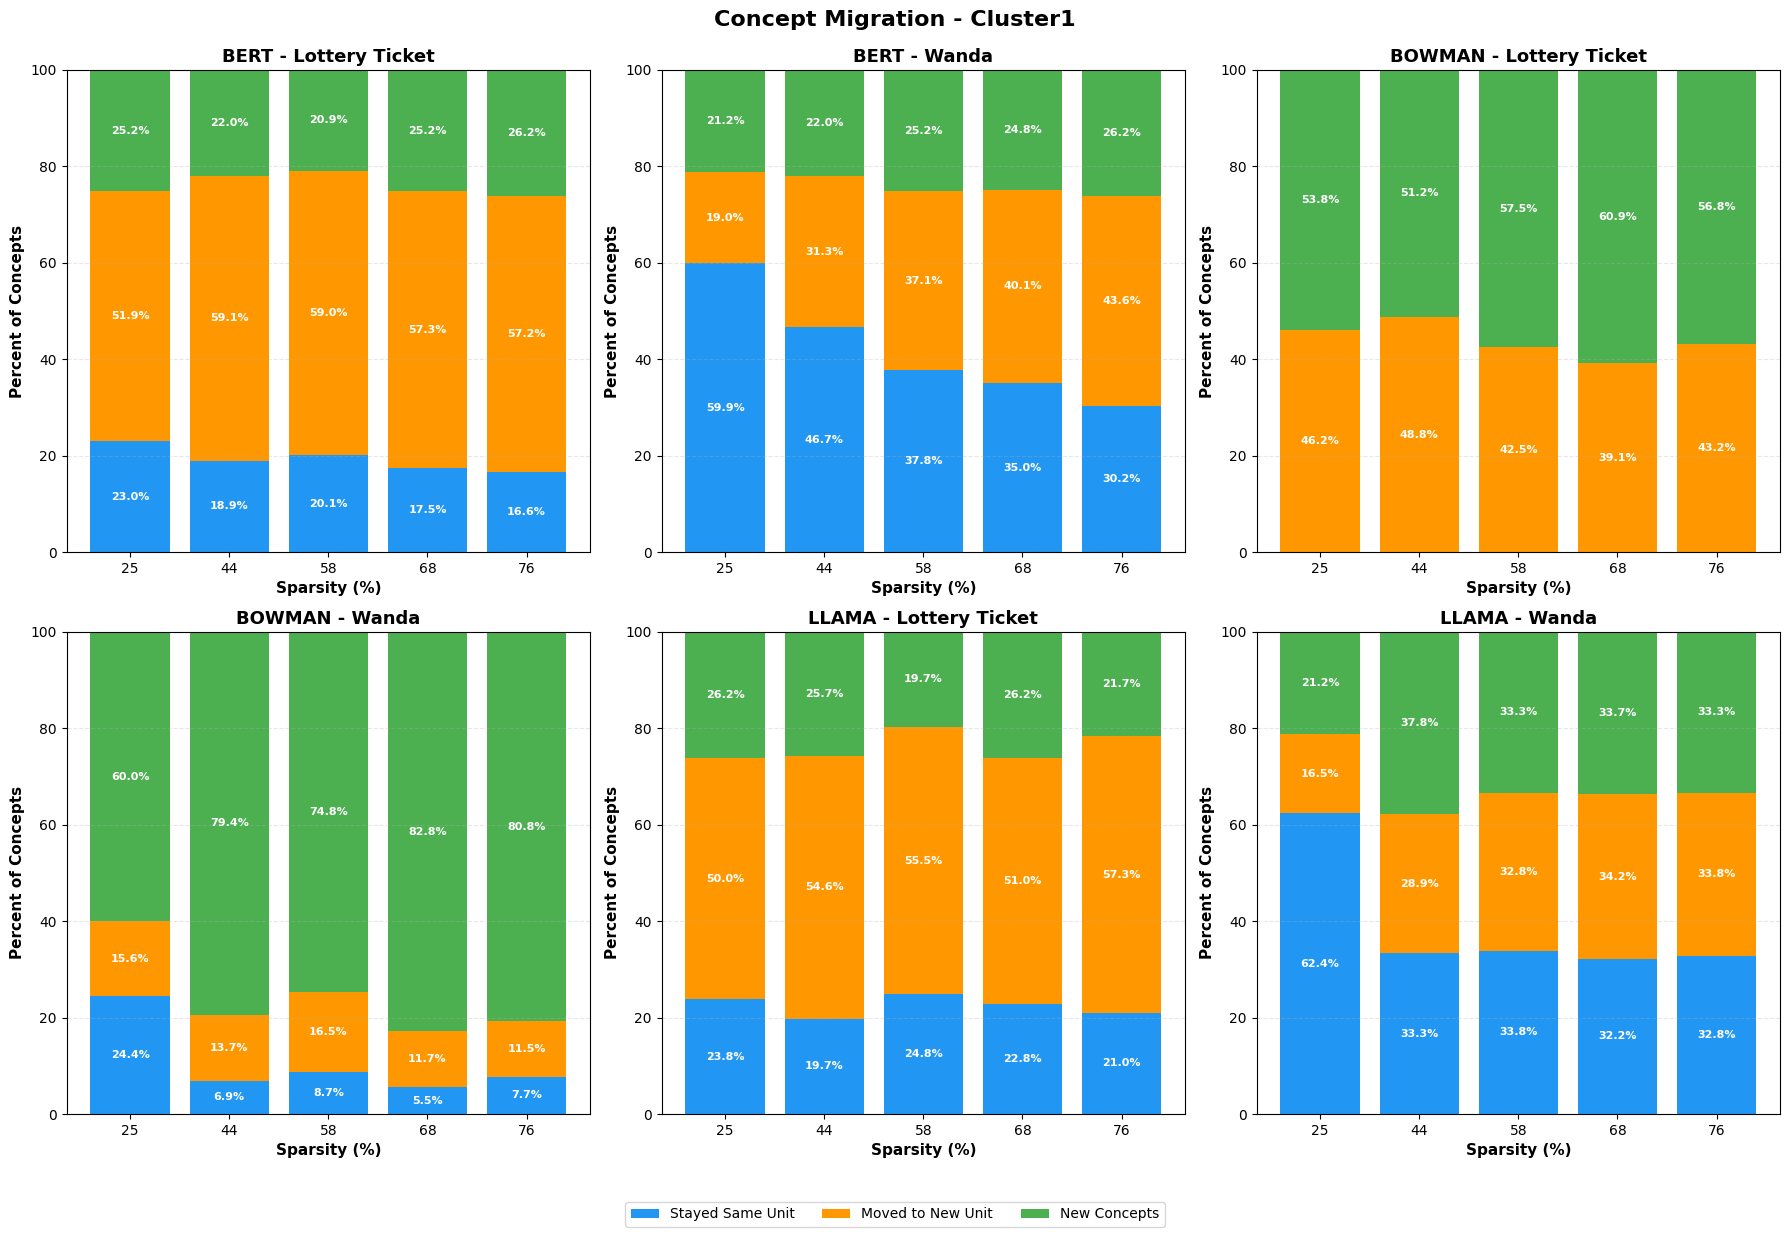


Concept migration plot for Cluster2 saved to 'multi_model_concept_migration_Cluster2.png'


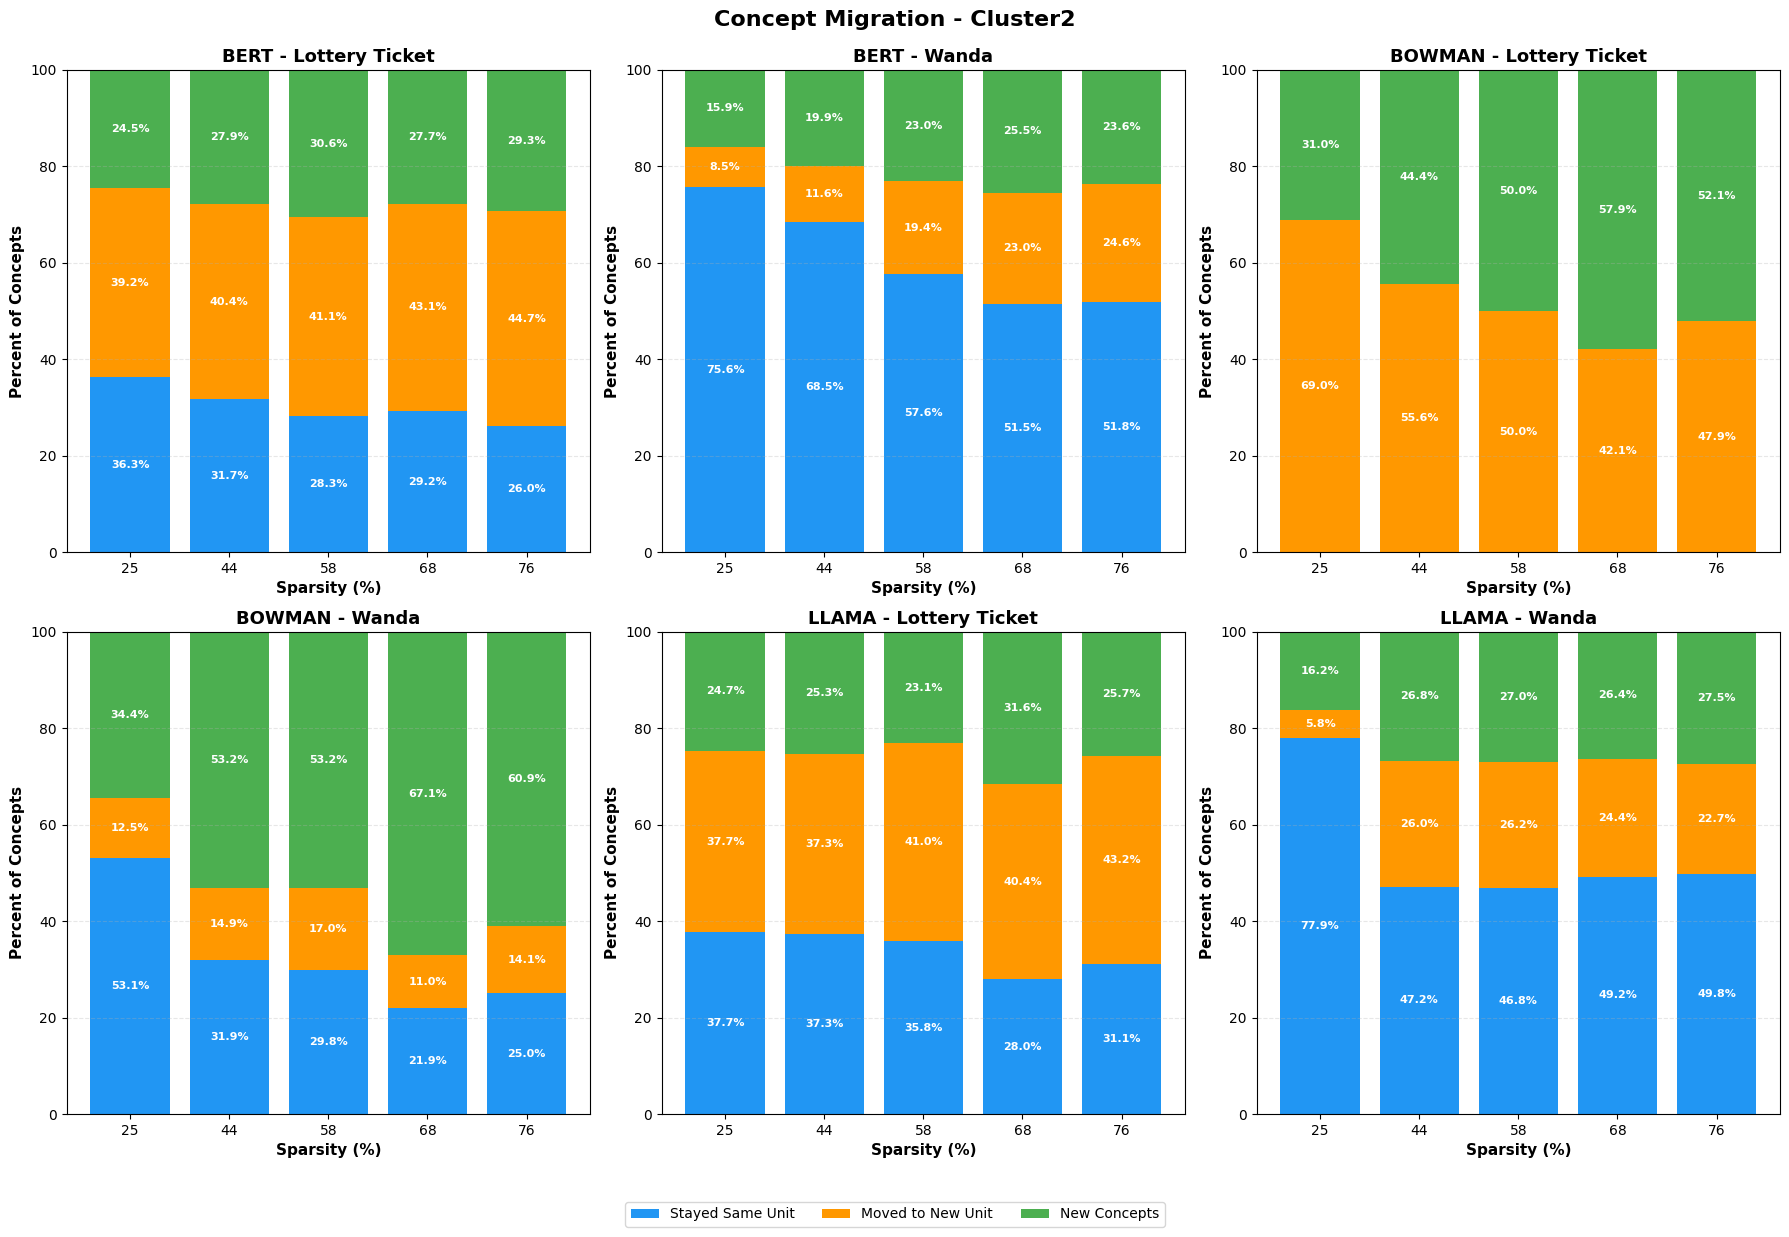


Concept migration plot for Cluster3 saved to 'multi_model_concept_migration_Cluster3.png'


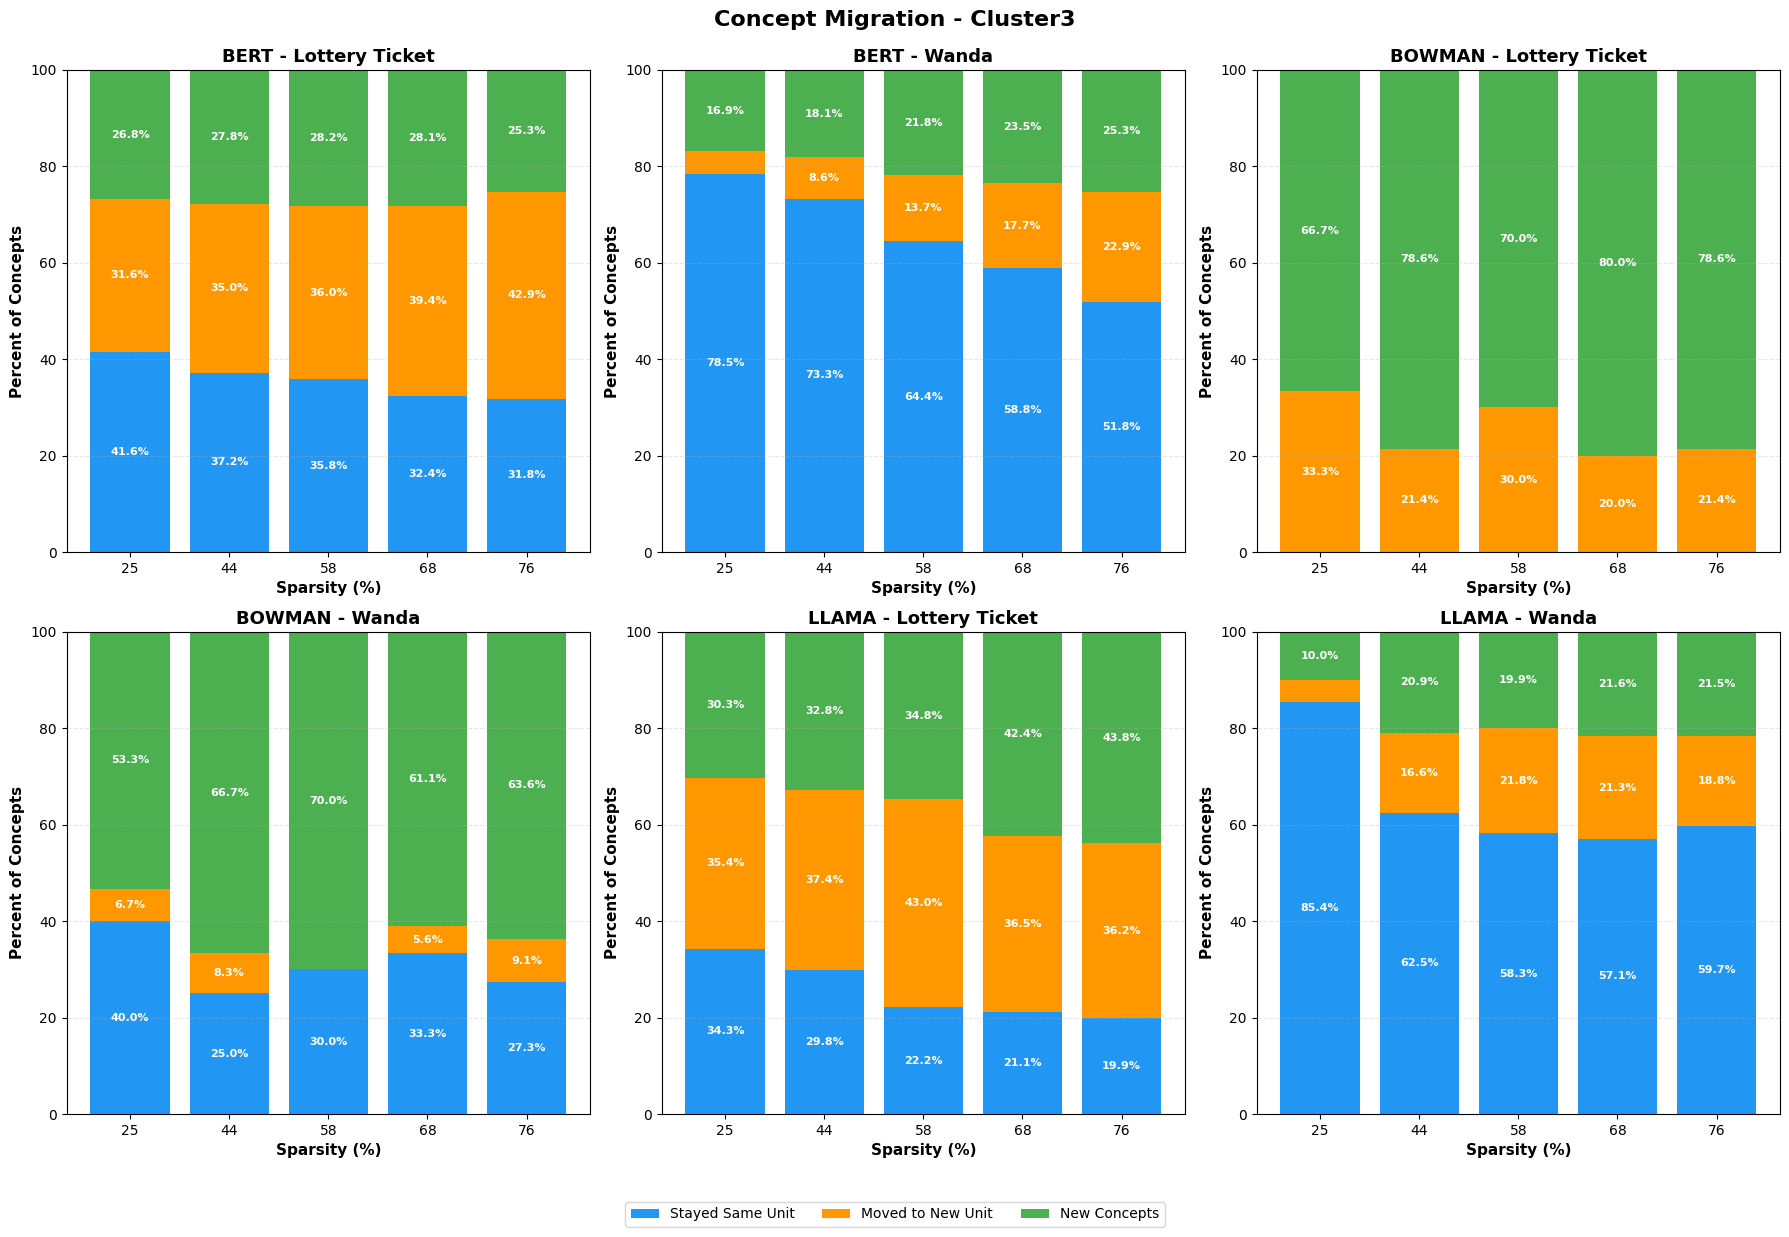


GENERATING CROSS-CLUSTER MIGRATION PLOTS

Cross-cluster migration plot saved to 'multi_model_cross_cluster_migration.png'


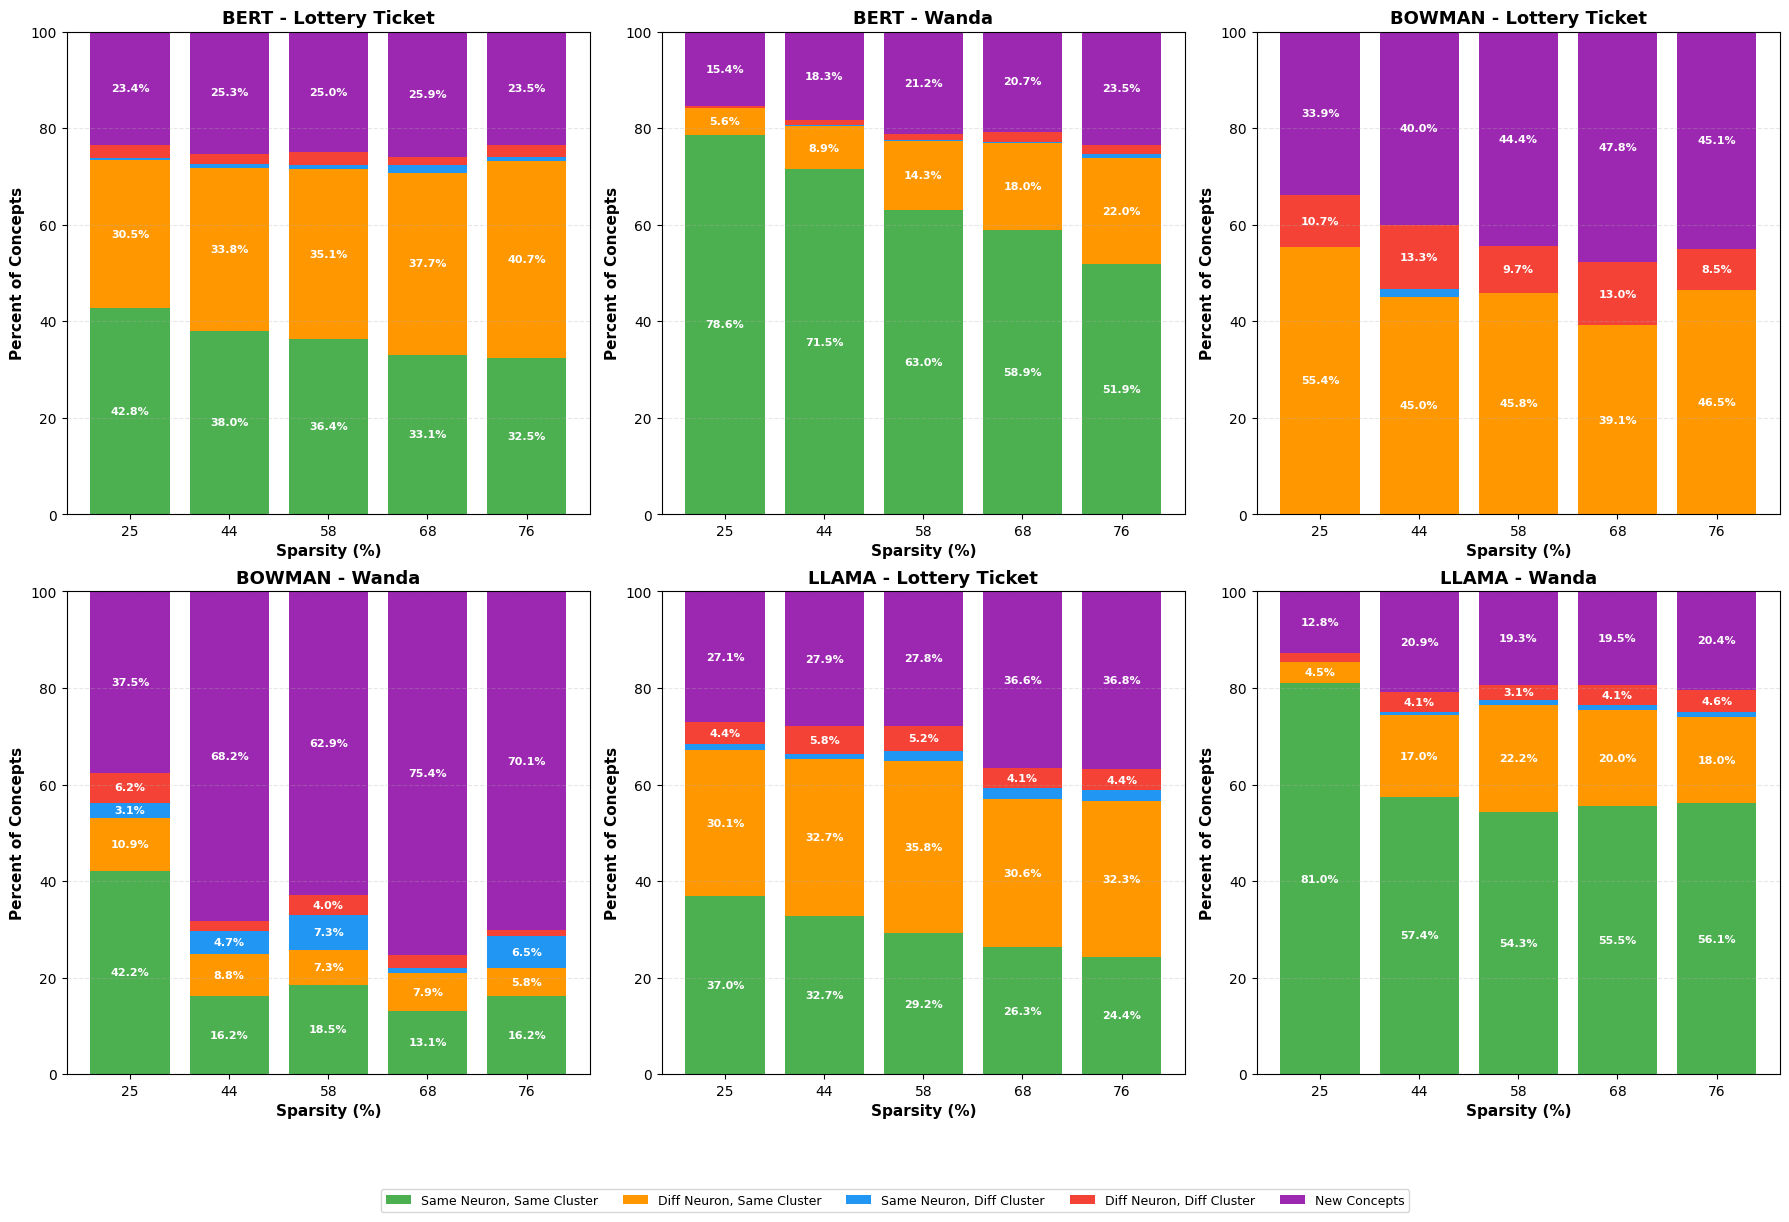


Lost concepts plot saved to 'lost_concepts.png'


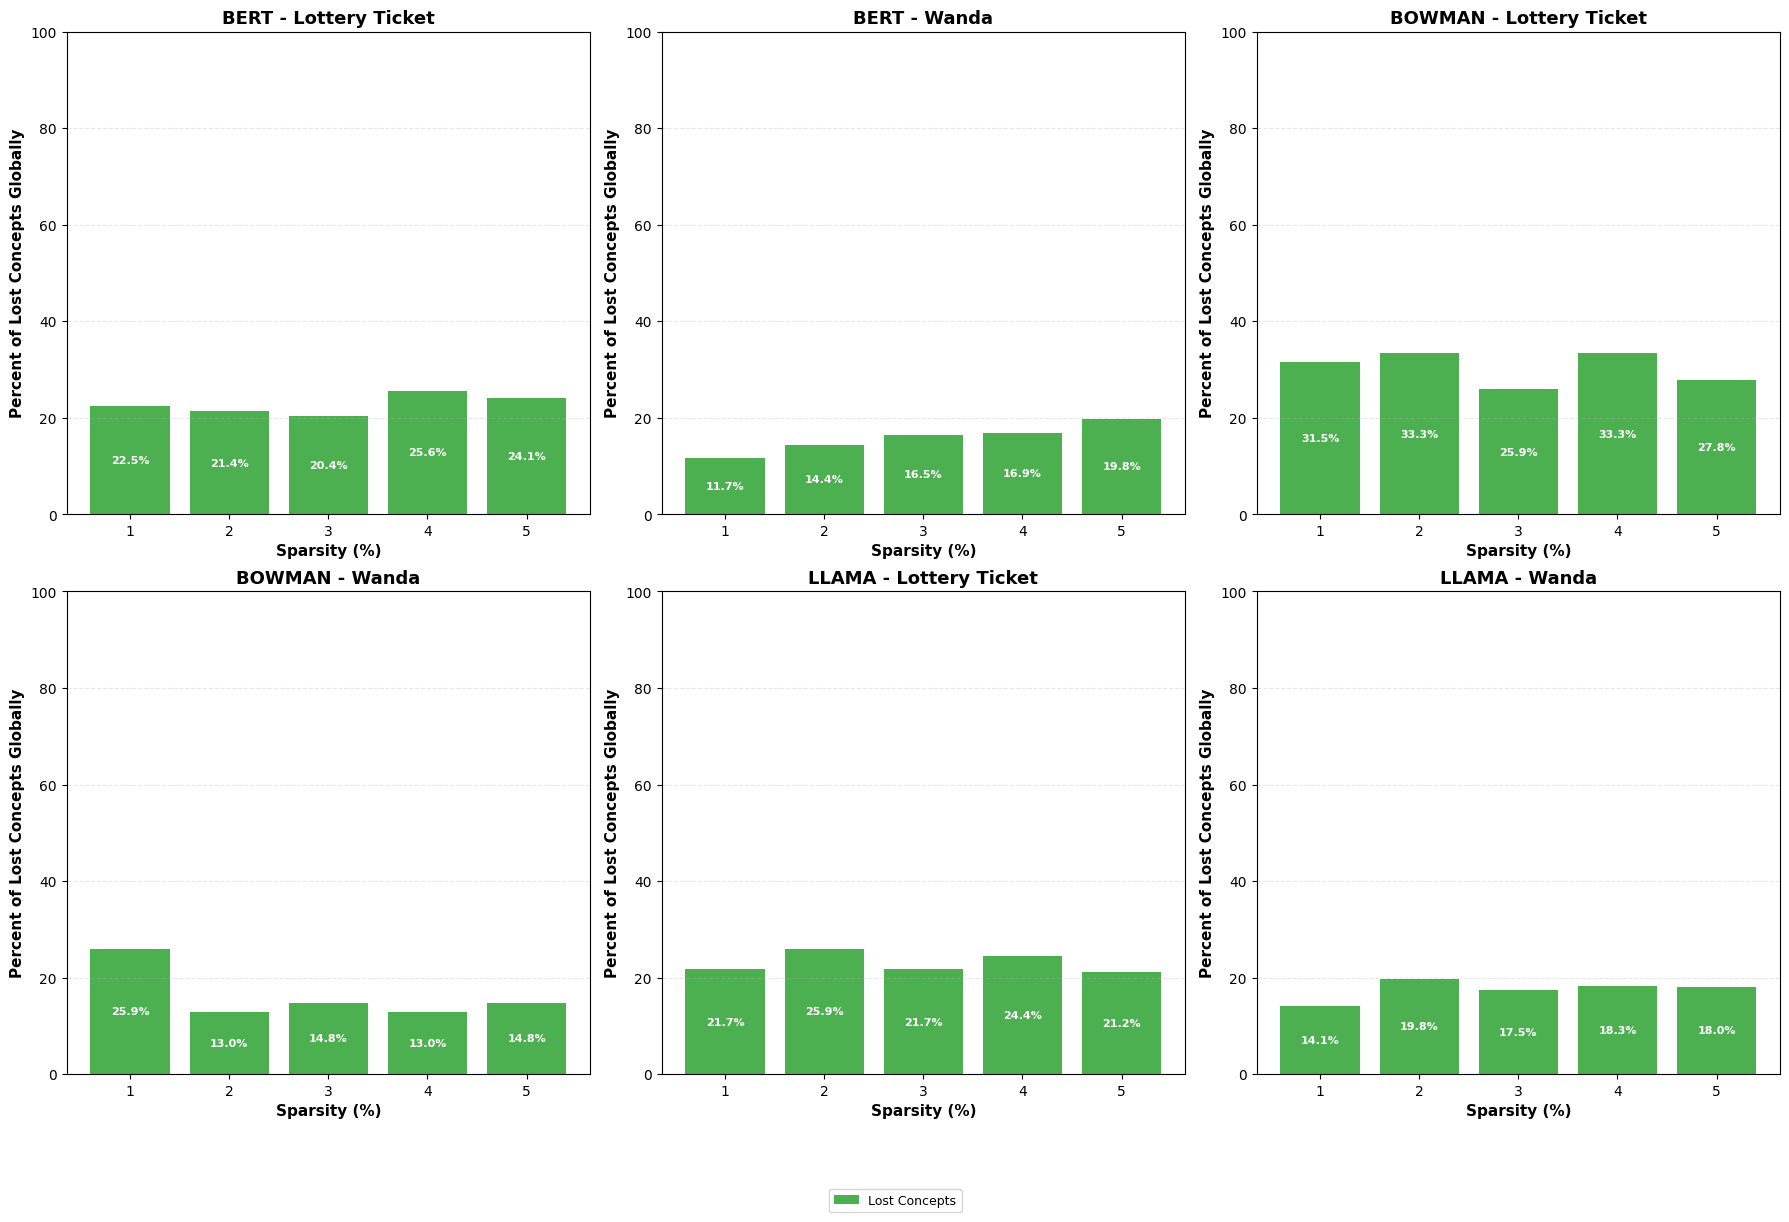

\Total concepts plot saved to 'ttl_concepts.png'


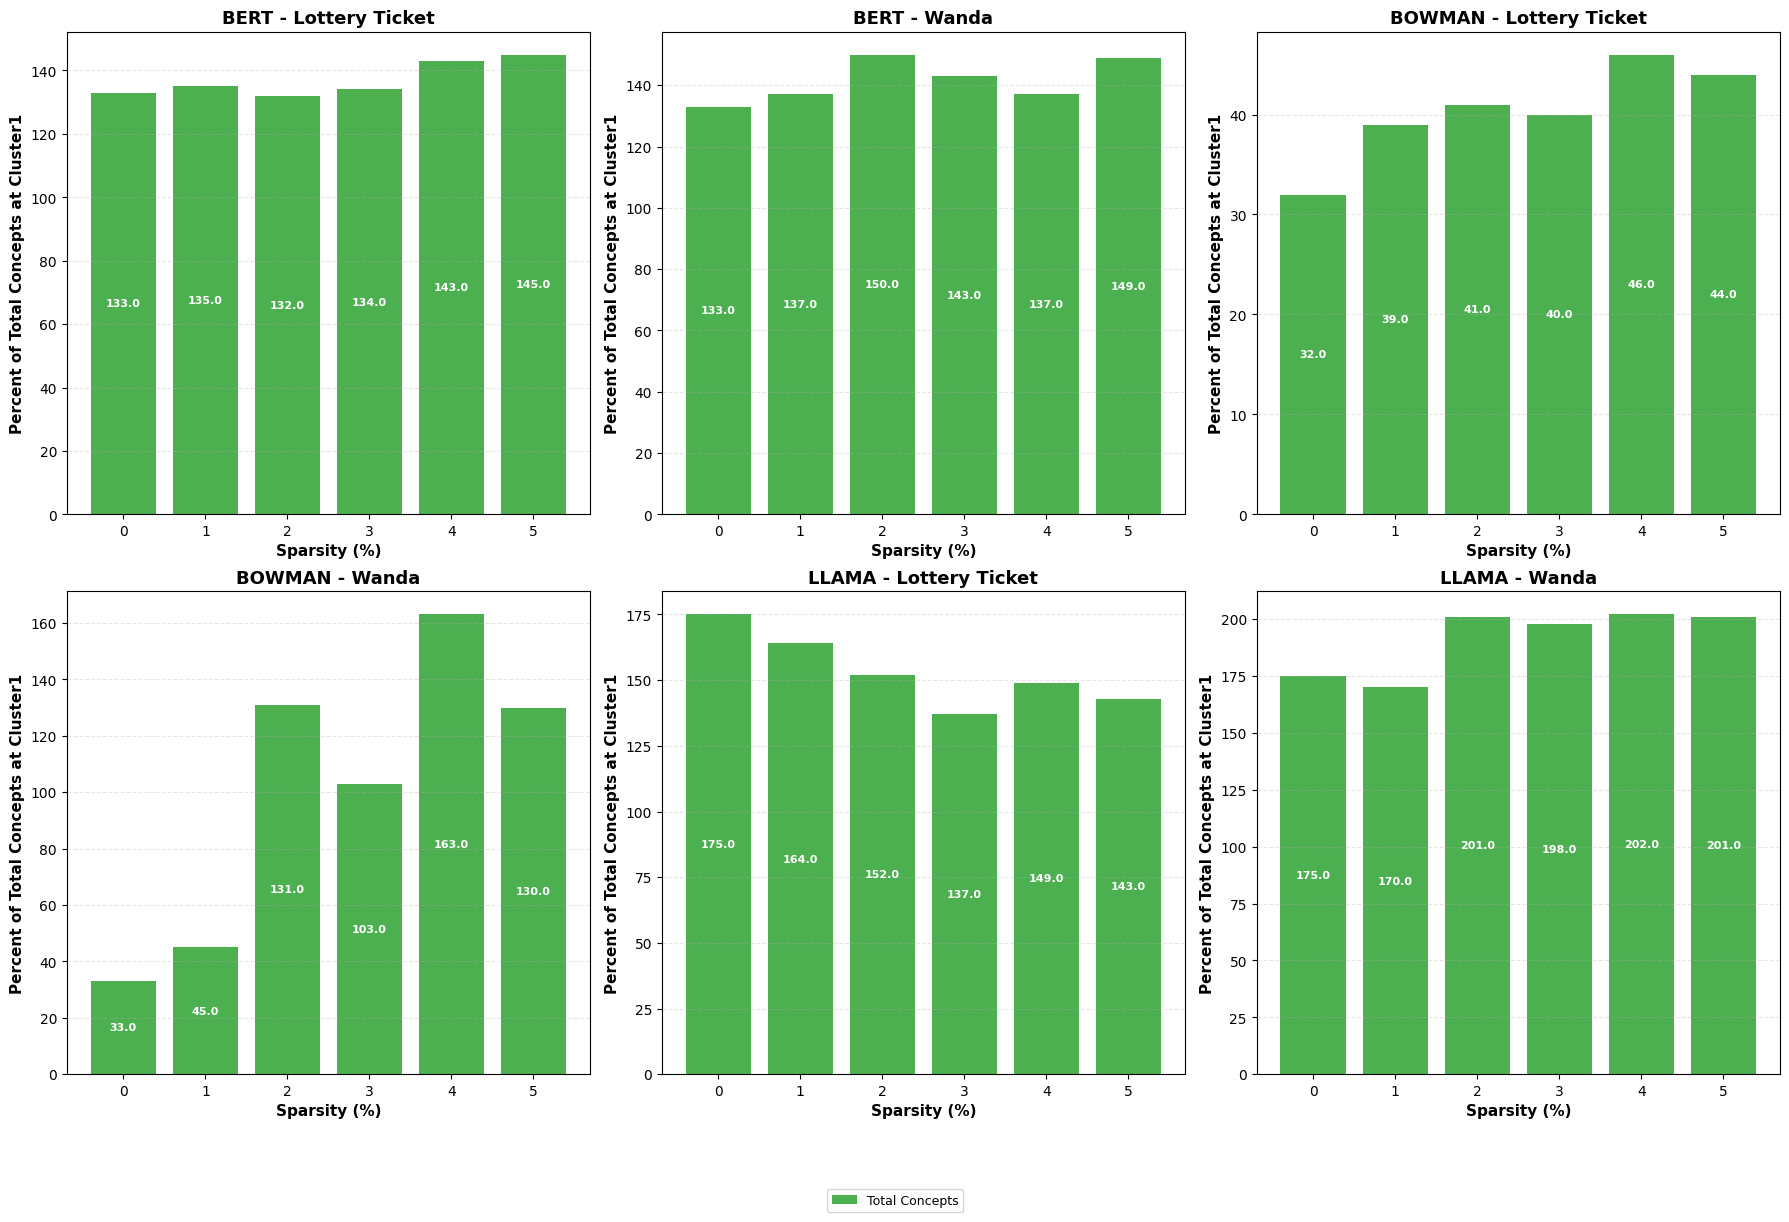

\Total concepts plot saved to 'ttl_concepts.png'


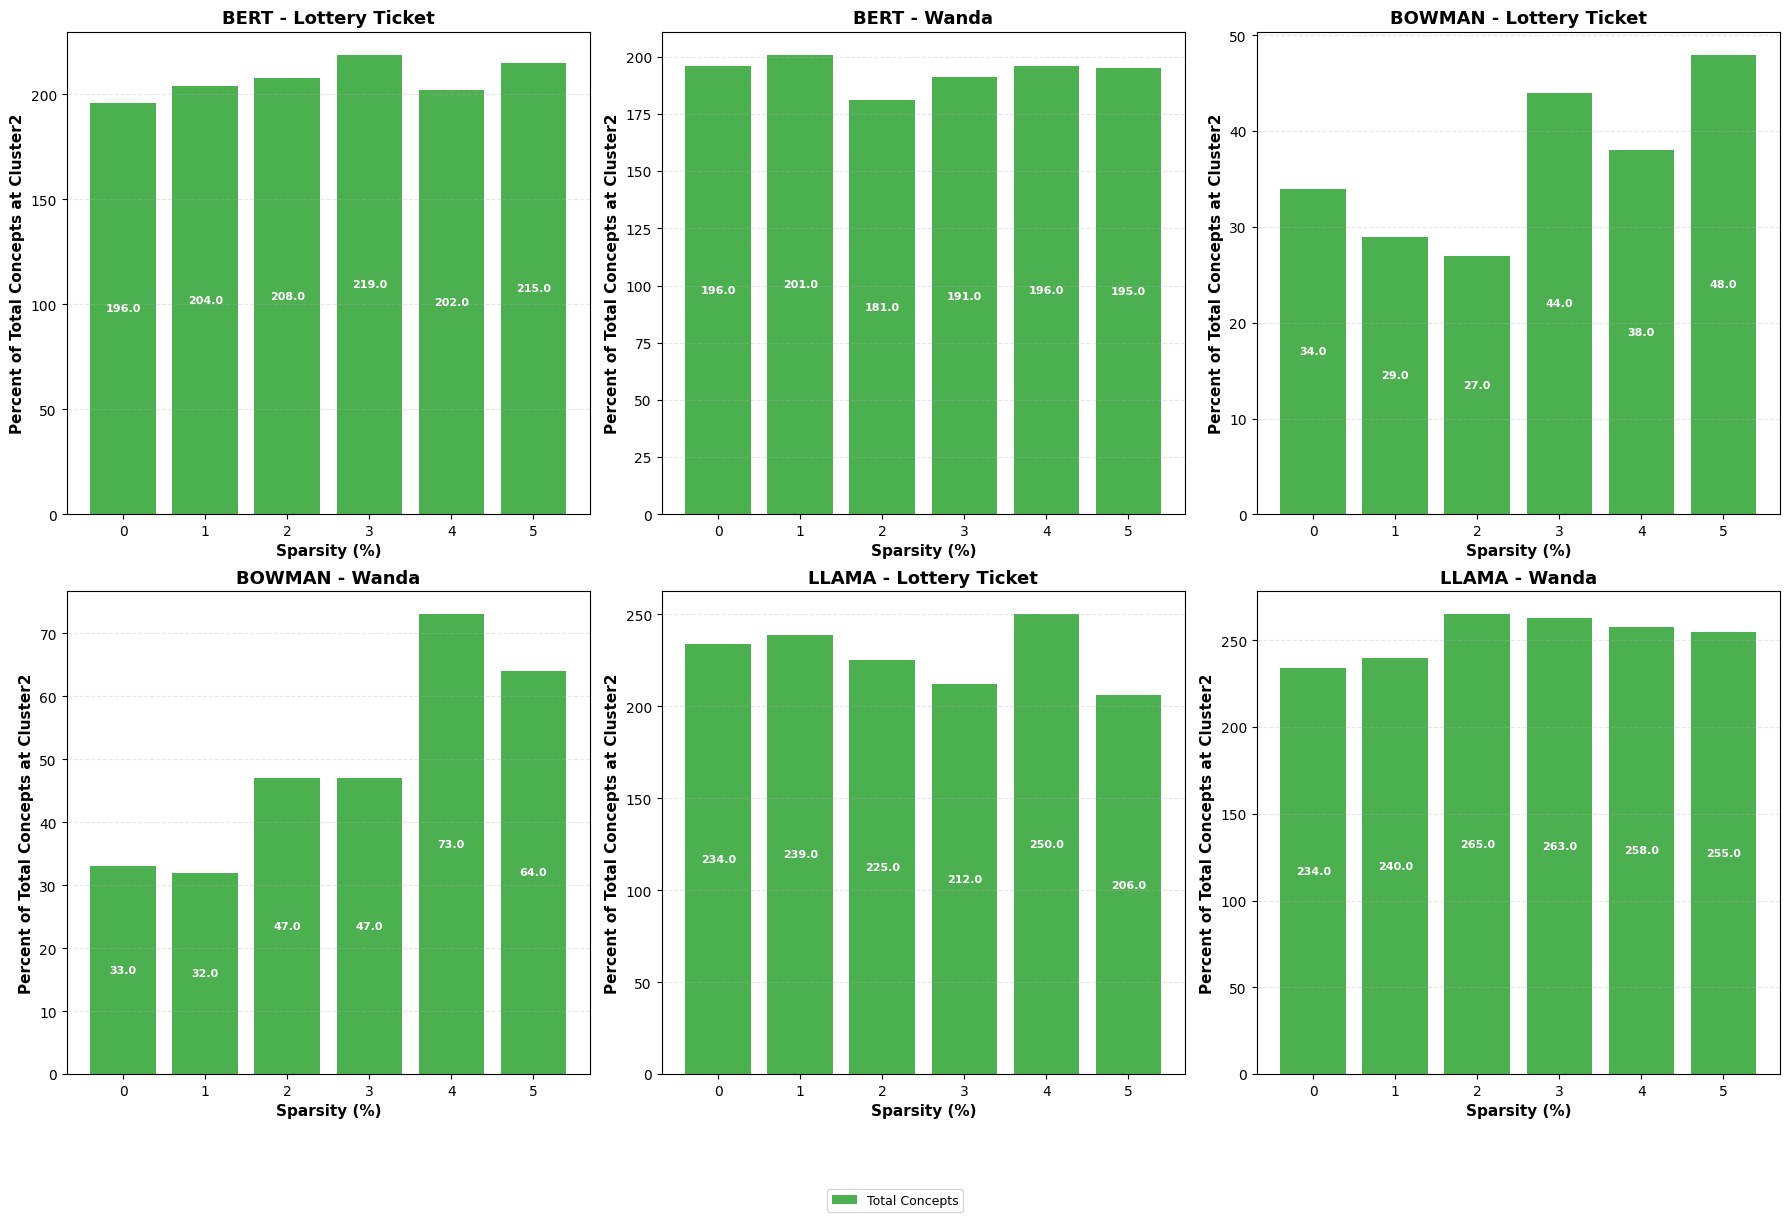

\Total concepts plot saved to 'ttl_concepts.png'


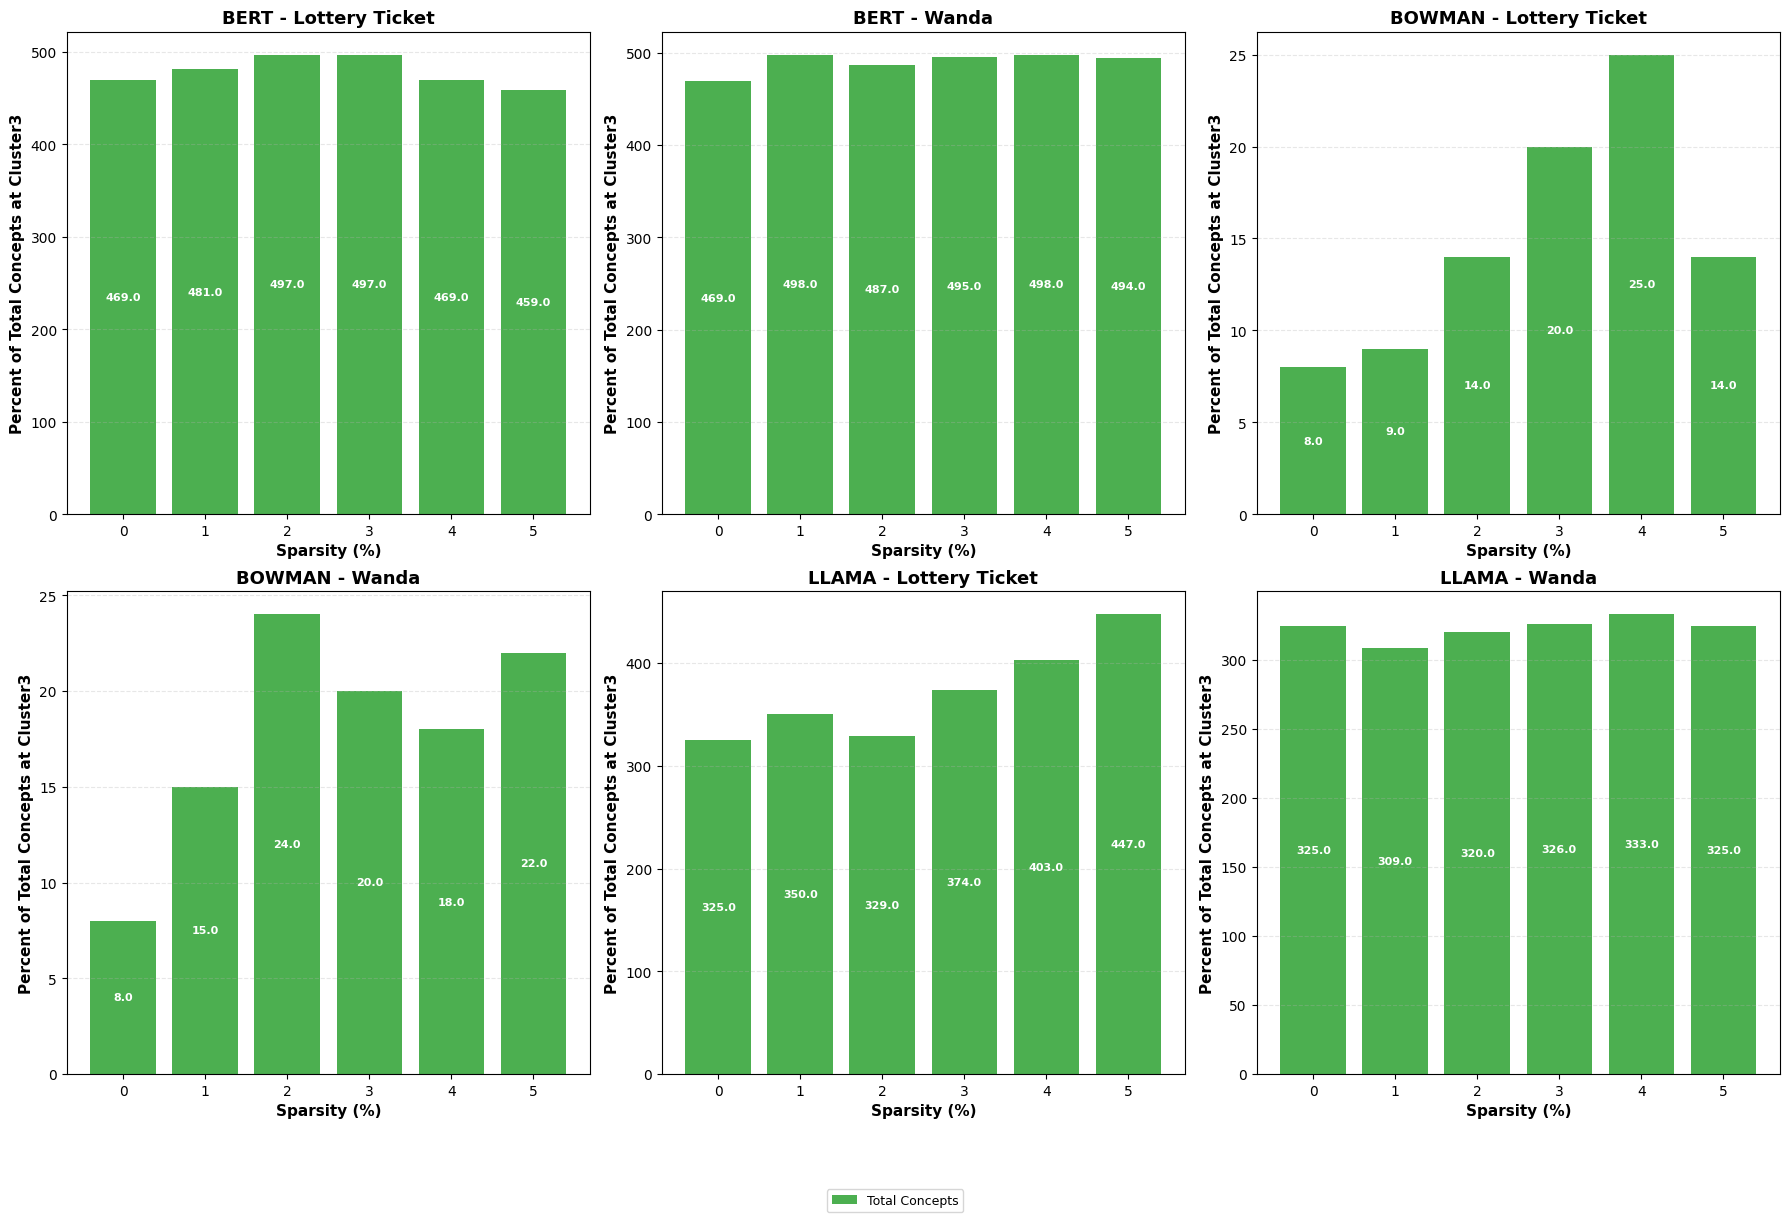

{'BERT': {'lottery_ticket': {'Cluster1': [{'iteration': 1, 'pruning_pct': 25.0, 'total_concepts_baseline': 133, 'total_concepts_curr': 135, 'new_concepts': 34, 'pct_new': 25.185185185185183, 'stayed_same': 31, 'pct_stayed_same': 22.962962962962962, 'moved_to_new_unit': 70, 'pct_moved_to_new': 51.85185185185185, 'disappeared_concepts': 32}, {'iteration': 2, 'pruning_pct': 43.75, 'total_concepts_baseline': 133, 'total_concepts_curr': 132, 'new_concepts': 29, 'pct_new': 21.96969696969697, 'stayed_same': 25, 'pct_stayed_same': 18.939393939393938, 'moved_to_new_unit': 78, 'pct_moved_to_new': 59.09090909090909, 'disappeared_concepts': 30}, {'iteration': 3, 'pruning_pct': 57.812, 'total_concepts_baseline': 133, 'total_concepts_curr': 134, 'new_concepts': 28, 'pct_new': 20.8955223880597, 'stayed_same': 27, 'pct_stayed_same': 20.149253731343283, 'moved_to_new_unit': 79, 'pct_moved_to_new': 58.95522388059702, 'disappeared_concepts': 27}, {'iteration': 4, 'pruning_pct': 68.359, 'total_concepts_ba

In [5]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

pi = {0: 0.0, 1: 25.0, 2: 43.75, 3: 57.812, 4: 68.359, 5: 76.27}

def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts


def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        unit_concepts[unit].update(concepts)
    
    return unit_concepts


def build_concept_to_units_mapping(unit_concepts_dict):
    """Build a mapping from concepts to all units that explain them."""
    concept_to_units = defaultdict(set)
    for unit, concepts in unit_concepts_dict.items():
        for concept in concepts:
            concept_to_units[concept].add(unit)
    return dict(concept_to_units)


def analyze_concept_migration(base_dir, num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """
    Analyze concept migration across pruning iterations for each cluster.
    All comparisons are made relative to iteration 0 (baseline).
    """
    results = {}
    
    for cluster in clusters:
        print(f"\nAnalyzing {cluster}")
        
        # Track concept-unit mappings across iterations
        iteration_data = []
        
        # Load data for all iterations
        for iteration in range(0, num_iterations + 1):
            csv_path = Path(base_dir) / f"{pi[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            
            if not csv_path.exists():
                print(f"Warning: {csv_path} not found, skipping...")
                continue
            
            unit_concepts = load_csv_data(csv_path)
            concept_to_units = build_concept_to_units_mapping(unit_concepts)
            
            iteration_data.append({
                'iteration': iteration,
                'unit_concepts': unit_concepts,
                'concept_to_units': concept_to_units,
                'all_concepts': set(concept_to_units.keys())
            })
        
        if len(iteration_data) == 0:
            print(f"No data found for {cluster}")
            continue
        
        # Get baseline (iteration 0)
        baseline = iteration_data[0]
        baseline_concepts = baseline['all_concepts']
        baseline_concept_to_units = baseline['concept_to_units']
        
        # Analyze each iteration compared to baseline
        cluster_results = []
        
        for i in range(1, len(iteration_data)):
            curr_iter = iteration_data[i]
            curr_concepts = curr_iter['all_concepts']
            curr_concept_to_units = curr_iter['concept_to_units']
            
            # Calculate metrics relative to baseline
            new_concepts = curr_concepts - baseline_concepts
            disappeared_concepts = baseline_concepts - curr_concepts
            common_concepts = baseline_concepts & curr_concepts
            
            # For common concepts, check overlap of units
            stayed_same = set()
            moved_to_new = set()
            
            for concept in common_concepts:
                baseline_units = baseline_concept_to_units[concept]
                curr_units = curr_concept_to_units[concept]
                
                if baseline_units & curr_units:
                    stayed_same.add(concept)
                else:
                    moved_to_new.add(concept)
            
            # Calculate percentages
            total_curr = len(curr_concepts)
            
            if total_curr > 0:
                pct_new = (len(new_concepts) / total_curr) * 100
                pct_stayed = (len(stayed_same) / total_curr) * 100
                pct_moved = (len(moved_to_new) / total_curr) * 100
            else:
                pct_new = pct_stayed = pct_moved = 0
            
            result = {
                'iteration': curr_iter['iteration'],
                'pruning_pct': pi[curr_iter['iteration']],
                'total_concepts_baseline': len(baseline_concepts),
                'total_concepts_curr': total_curr,
                'new_concepts': len(new_concepts),
                'pct_new': pct_new,
                'stayed_same': len(stayed_same),
                'pct_stayed_same': pct_stayed,
                'moved_to_new_unit': len(moved_to_new),
                'pct_moved_to_new': pct_moved,
                'disappeared_concepts': len(disappeared_concepts)
            }
            
            cluster_results.append(result)
        
        results[cluster] = cluster_results
    
    return results


def analyze_cross_cluster_migration(base_dir, num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """Analyze concept migration across neurons and clusters."""
    
    # Load baseline (iteration 0) for all clusters
    baseline_cluster_data = {}
    baseline_concept_map = defaultdict(lambda: defaultdict(set))
    
    for cluster in clusters:
        csv_path = Path(base_dir) / f"{pi[0]}%Pruned" / f"{cluster}IOUS1024N.csv"
        if not csv_path.exists():
            continue
        
        unit_concepts = load_csv_data(csv_path)
        baseline_cluster_data[cluster] = unit_concepts
        
        for unit, concepts in unit_concepts.items():
            for concept in concepts:
                baseline_concept_map[concept][cluster].add(unit)
    
    all_baseline_concepts = set(baseline_concept_map.keys())
    migration_results = []
    
    for iteration in range(1, num_iterations + 1):
        current_cluster_data = {}
        current_concept_map = defaultdict(lambda: defaultdict(set))
        
        for cluster in clusters:
            csv_path = Path(base_dir) / f"{pi[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            if not csv_path.exists():
                continue
            
            unit_concepts = load_csv_data(csv_path)
            current_cluster_data[cluster] = unit_concepts
            
            for unit, concepts in unit_concepts.items():
                for concept in concepts:
                    current_concept_map[concept][cluster].add(unit)
        
        all_current_concepts = set(current_concept_map.keys())
        
        # Categorize concepts
        same_neuron_same_cluster = set()
        same_neuron_diff_cluster = set()
        diff_neuron_same_cluster = set()
        diff_neuron_diff_cluster = set()
        new_concepts = all_current_concepts - all_baseline_concepts
        disappeared_concepts = all_baseline_concepts - all_current_concepts
        
        common_concepts = all_baseline_concepts & all_current_concepts
        
        for concept in common_concepts:
            baseline_clusters = baseline_concept_map[concept]
            current_clusters = current_concept_map[concept]
            
            # Check if concept stayed in exact same locations
            has_exact_match = False
            for cluster in baseline_clusters:
                if cluster in current_clusters:
                    if baseline_clusters[cluster] & current_clusters[cluster]:
                        has_exact_match = True
                        break
            
            if has_exact_match:
                same_neuron_same_cluster.add(concept)
                continue
            
            # Check for cross-cluster neuron migration
            cross_cluster_migration = False
            
            for orig_cluster in baseline_clusters:
                baseline_units = baseline_clusters[orig_cluster]
                
                for other_cluster in current_clusters:
                    if other_cluster == orig_cluster:
                        continue
                    
                    current_units = current_clusters[other_cluster]
                    
                    for unit in baseline_units:
                        if unit in current_units and unit not in baseline_concept_map[concept].get(other_cluster, set()):
                            cross_cluster_migration = True
                            break
                    
                    if cross_cluster_migration:
                        break
                
                if cross_cluster_migration:
                    break
            
            if cross_cluster_migration:
                same_neuron_diff_cluster.add(concept)
                continue
            
            # Check if concept stayed in same cluster(s) but with different neurons
            has_same_cluster = False
            for cluster in baseline_clusters:
                if cluster in current_clusters:
                    has_same_cluster = True
                    break
            
            if has_same_cluster:
                diff_neuron_same_cluster.add(concept)
            else:
                diff_neuron_diff_cluster.add(concept)
        
        # Calculate counts and percentages
        total_baseline = len(all_baseline_concepts)
        total_current = len(all_current_concepts)
        
        result = {
            'iteration': iteration,
            'pruning_pct': pi[iteration],
            'total_baseline_concepts': total_baseline,
            'total_current_concepts': total_current,
            'same_neuron_same_cluster': len(same_neuron_same_cluster),
            'same_neuron_diff_cluster': len(same_neuron_diff_cluster),
            'diff_neuron_same_cluster': len(diff_neuron_same_cluster),
            'diff_neuron_diff_cluster': len(diff_neuron_diff_cluster),
            'new_concepts': len(new_concepts),
            'disappeared_concepts': len(disappeared_concepts),
        }
        
        
        
        # Add percentages
        if total_current > 0:
            result['pct_same_neuron_same_cluster'] = (len(same_neuron_same_cluster) / total_current) * 100
            result['pct_same_neuron_diff_cluster'] = (len(same_neuron_diff_cluster) / total_current) * 100
            result['pct_diff_neuron_same_cluster'] = (len(diff_neuron_same_cluster) / total_current) * 100
            result['pct_diff_neuron_diff_cluster'] = (len(diff_neuron_diff_cluster) / total_current) * 100
            result['pct_new_concepts'] = (len(new_concepts) / total_current) * 100
            result['lost_concepts']=(result['disappeared_concepts']/len(all_baseline_concepts)) *100
           
        else:
            result['pct_same_neuron_same_cluster'] = 0
            result['pct_same_neuron_diff_cluster'] = 0
            result['pct_diff_neuron_same_cluster'] = 0
            result['pct_diff_neuron_diff_cluster'] = 0
            result['pct_new_concepts'] = 0
            print(f"{pi[iteration]}%Pruned")
        
        migration_results.append(result)
        
        '''print(f"Iteration: {result['iteration']}\n{result['pruning_pct']}% Sparse")
        print(f"% Same neuron same cluster: {result['pct_same_neuron_same_cluster']}")
        print(f"% Same neuron different cluster: {result['pct_same_neuron_diff_cluster']}")
        print(f"% Different neuron same cluster: {result['pct_diff_neuron_same_cluster']}")
        print(f"% New concepts: {result['pct_new_concepts']}")
        print(f"% Lost concepts: {result['disappeared_concepts']/len(all_baseline_concepts)}")'''
    
    return migration_results


def analyze_all_models_methods(base_path_template, models, methods, run='Run0.25'):
    """
    Analyze all model-method combinations for both per-cluster and cross-cluster migration.
    
    Returns:
        {
            'per_cluster': {model: {method: results}},
            'cross_cluster': {model: {method: migration_results}}
        }
    """
    per_cluster_results = {}
    cross_cluster_results = {}
    
    for model in models:
        per_cluster_results[model] = {}
        cross_cluster_results[model] = {}
        
        for method in methods:
            print(f"\n{'='*80}")
            print(f"Processing: {model} - {method}")
            print(f"{'='*80}")
            
            # Construct path
            base_dir = base_path_template.format(model=model.upper(), method=method, run=run)
            
            # Check if directory exists
            if not Path(base_dir).exists():
                print(f"Warning: Directory not found: {base_dir}")
                per_cluster_results[model][method] = None
                cross_cluster_results[model][method] = None
                continue
            
            # Run analyses
            try:
                print("Running per-cluster analysis...")
                per_cluster = analyze_concept_migration(base_dir)
                per_cluster_results[model][method] = per_cluster
                
                print("Running cross-cluster analysis...")
                cross_cluster = analyze_cross_cluster_migration(base_dir)
                cross_cluster_results[model][method] = cross_cluster
                
                print(f"✓ Successfully analyzed {model} - {method}")
            except Exception as e:
                print(f"✗ Error analyzing {model} - {method}: {e}")
                per_cluster_results[model][method] = None
                cross_cluster_results[model][method] = None
    
    return {
        'per_cluster': per_cluster_results,
        'cross_cluster': cross_cluster_results
    }


def plot_multi_model_concept_migration(per_cluster_results, models, methods, 
                                       save_path='multi_model_concept_migration.png',
                                       clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """
    Create subplots for concept migration (per-cluster analysis).
    Each subplot shows one model-method combination for ONE specific cluster.
    Creates separate plots for each cluster.
    """
    for cluster in clusters:
        valid_combos = []
        for model in models:
            for method in methods:
                if per_cluster_results.get(model, {}).get(method) is not None:
                    if cluster in per_cluster_results[model][method]:
                        valid_combos.append((model, method))
        
        if not valid_combos:
            print(f"No valid per-cluster results to plot for {cluster}!")
            continue
        
        num_combos = len(valid_combos)
        ncols = min(3, num_combos)
        nrows = (num_combos + ncols - 1) // ncols
        
        fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
        
        if num_combos == 1:
            axes = np.array([axes])
        axes = axes.flatten() if num_combos > 1 else axes
        
        for idx, (model, method) in enumerate(valid_combos):
            ax = axes[idx]
            cluster_results = per_cluster_results[model][method][cluster]
            
            # Extract data for this cluster
            iterations = [r['iteration'] for r in cluster_results]
            pct_new = [r['pct_new'] for r in cluster_results]
            pct_stayed = [r['pct_stayed_same'] for r in cluster_results]
            pct_moved = [r['pct_moved_to_new'] for r in cluster_results]
            
            # Create stacked bar chart
            x = np.arange(len(iterations))
            
            p1 = ax.bar(x, pct_stayed, label='Stayed Same Unit', color='#2196F3')
            p2 = ax.bar(x, pct_moved, bottom=pct_stayed, label='Moved to New Unit', color='#FF9800')
            p3 = ax.bar(x, pct_new, bottom=np.array(pct_stayed)+np.array(pct_moved), 
                       label='New Concepts', color='#4CAF50')
            
            # Add percentage labels
            for i in range(len(iterations)):
                if pct_stayed[i] > 5:
                    ax.text(i, pct_stayed[i]/2, f'{pct_stayed[i]:.1f}%',
                           ha='center', va='center', fontsize=8, fontweight='bold', color='white')
                if pct_moved[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i]/2, f'{pct_moved[i]:.1f}%',
                           ha='center', va='center', fontsize=8, fontweight='bold', color='white')
                if pct_new[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i] + pct_new[i]/2, f'{pct_new[i]:.1f}%',
                           ha='center', va='center', fontsize=8, fontweight='bold', color='white')
            
            # Customize subplot
            ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Percent of Concepts', fontsize=11, fontweight='bold')
            ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                         fontsize=13, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels([f'{pi[it]:.0f}' for it in iterations])
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(0, 100)
        
        # Hide empty subplots
        for idx in range(num_combos, len(axes)):
            axes[idx].axis('off')
        
        # Add shared legend
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10,
                   bbox_to_anchor=(0.5, -0.02), frameon=True)
        
        # Add main title for the cluster
        fig.suptitle(f'Concept Migration - {cluster}', fontsize=16, fontweight='bold', y=1.0)
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.08, top=0.95)
        
        # Save with cluster name
        cluster_save_path = save_path.replace('.png', f'_{cluster}.png')
        plt.savefig(cluster_save_path, dpi=300, bbox_inches='tight')
        print(f"\nConcept migration plot for {cluster} saved to '{cluster_save_path}'")
        plt.show()
def plot_lost_concepts(per_iteration_results, models, methods, 
                                       save_path='lost_concepts.png',
                                       pi=5):
    """
    Create subplots for concept migration (per-cluster analysis).
    Each subplot shows one model-method combination for ONE specific cluster.
    Creates separate plots for each cluster.
    """
    valid_combos = []
    for model in models:
        for method in methods:
            if per_iteration_results.get(model, {}).get(method) is not None:
                valid_combos.append((model, method))
    
    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return
    
    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
    
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes
    
    colors = {
        'same_neuron_same_cluster': '#4CAF50',
        'same_neuron_diff_cluster': '#2196F3',
        'diff_neuron_same_cluster': '#FF9800',
        'diff_neuron_diff_cluster': '#F44336',
        'new_concepts': '#9C27B0'
    }
    
    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = per_iteration_results[model][method]
    
        lost_concepts=[]
        # Extract data
        for r in  migration_results:
            if 'lost_concepts' not in r:
                print(model, method)
            else:
                lost_concepts.append(r['lost_concepts'] )
        
        
        x = np.arange(len(migration_results))
        
        # Create stacked bars
        p1 = ax.bar(x, lost_concepts, label='Lost Concepts', 
                    color=colors['same_neuron_same_cluster'])
       
        for bars in [p1]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2.,
                            height / 2,
                            f'{height:.1f}%',
                            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        
        # Customize subplot
        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Lost Concepts Globally', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                     fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{r["iteration"]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)
    
    # Hide empty subplots
    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')
    
    # Add shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nLost concepts plot saved to '{save_path}'")
    plt.show()



def plot_multi_model_cross_cluster_migration(cross_cluster_results, models, methods,
                                             save_path='multi_model_cross_cluster_migration.png'):
    """
    Create subplots for cross-cluster migration analysis.
    Each subplot shows one model-method combination.
    """
    valid_combos = []
    for model in models:
        for method in methods:
            if cross_cluster_results.get(model, {}).get(method) is not None:
                valid_combos.append((model, method))
    
    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return
    
    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
    
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes
    
    colors = {
        'same_neuron_same_cluster': '#4CAF50',
        'diff_neuron_same_cluster': '#FF9800',
        'same_neuron_diff_cluster': '#2196F3',
        'diff_neuron_diff_cluster': '#F44336',
        'new_concepts': '#9C27B0'
    }
    
    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = cross_cluster_results[model][method]
        
        # Extract data
        same_n_same_c = [r['pct_same_neuron_same_cluster'] for r in migration_results]
        same_n_diff_c = [r['pct_same_neuron_diff_cluster'] for r in migration_results]
        diff_n_same_c = [r['pct_diff_neuron_same_cluster'] for r in migration_results]
        diff_n_diff_c = [r['pct_diff_neuron_diff_cluster'] for r in migration_results]
        new_concepts = [r['pct_new_concepts'] for r in migration_results]
        
        x = np.arange(len(migration_results))
        
        # Create stacked bars
        p1 = ax.bar(x, same_n_same_c, label='Same Neuron, Same Cluster', 
                    color=colors['same_neuron_same_cluster'])
        p2 = ax.bar(x, diff_n_same_c,
                    bottom=same_n_same_c,
                    label='Diff Neuron, Same Cluster', 
                    color=colors['diff_neuron_same_cluster'])
        
        p3 = ax.bar(x, same_n_diff_c, bottom= np.array(same_n_same_c)+ np.array(diff_n_same_c),
                    label='Same Neuron, Diff Cluster', 
                    color=colors['same_neuron_diff_cluster'])
        p4 = ax.bar(x, diff_n_diff_c,
                    bottom=np.array(same_n_same_c) +  np.array(diff_n_same_c) + np.array(same_n_diff_c) ,
                    label='Diff Neuron, Diff Cluster', 
                    color=colors['diff_neuron_diff_cluster'])
        p5 = ax.bar(x, new_concepts,
                    bottom=np.array(same_n_same_c) + np.array(same_n_diff_c) + 
                           np.array(diff_n_same_c) + np.array(diff_n_diff_c),
                    label='New Concepts', 
                    color=colors['new_concepts'])
        
        # Add value labels
        bar_containers = [p1, p2, p3, p4, p5]
        bottoms = [
            np.zeros(len(x)),
            np.array(same_n_same_c),
            np.array(same_n_same_c) + np.array(diff_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + 
            np.array(diff_n_same_c) + np.array(diff_n_diff_c)
        ]
        
        for bars, bottom in zip(bar_containers, bottoms):
            for bar, base in zip(bars, bottom):
                height = bar.get_height()
                if height > 3:
                    ax.text(bar.get_x() + bar.get_width() / 2.,
                            base + height / 2,
                            f'{height:.1f}%',
                            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        
        # Customize subplot
        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Concepts', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                     fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{pi[r["iteration"]]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)
    
    # Hide empty subplots
    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')
    
    # Add shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nCross-cluster migration plot saved to '{save_path}'")
    plt.show()

def plot_num_concepts(per_iteration_results, models, methods, 
                                       save_path='ttl_concepts.png',
                                       pi=5,clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """
    Create subplots for concept migration (per-cluster analysis).
    Each subplot shows one model-method combination for ONE specific cluster.
    Creates separate plots for each cluster.
    """
    for cluster in clusters:
        valid_combos = []
        for model in models:
            for method in methods:
                if per_iteration_results.get(model, {}).get(method) is not None:
                    valid_combos.append((model, method))

        if not valid_combos:
            print("No valid total concepts results to plot!")
            return

        num_combos = len(valid_combos)
        ncols = min(3, num_combos)
        nrows = (num_combos + ncols - 1) // ncols

        fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))

        if num_combos == 1:
            axes = np.array([axes])
        axes = axes.flatten() if num_combos > 1 else axes

        colors = {
            'total_concepts_curr': '#4CAF50',
        }

        for idx, (model, method) in enumerate(valid_combos):
            ax = axes[idx]
            migration_results = per_iteration_results[model][method][cluster]

            total_concepts=[]
            # Extract data
            for r in  migration_results:
                if 'total_concepts_curr' not in r:
                    print(model, method)
                else:
                    total_concepts.append(r['total_concepts_curr'] )

            total_concepts.insert(0,r['total_concepts_baseline'] )
            x = np.arange(len(migration_results)+1)

            # Create stacked bars
            p1 = ax.bar(x, total_concepts, label='Total Concepts', 
                        color=colors['total_concepts_curr'])

            for bars in [p1]:
                for bar in bars:
                    height = bar.get_height()
                    if height > 0:
                        ax.text(bar.get_x() + bar.get_width() / 2.,
                                height / 2,
                                f'{height:.1f}',
                                ha='center', va='center', fontsize=8, fontweight='bold', color='white')

            # Customize subplot
            ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
            ax.set_ylabel(f'Percent of Total Concepts at {cluster}', fontsize=11, fontweight='bold')
            ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                         fontsize=13, fontweight='bold')
            ax.set_xticks(x)
            x_labels=[0]
            x_labels.extend([f'{r["iteration"]:.0f}' for r in migration_results])
            ax.set_xticklabels(x_labels)
            ax.grid(axis='y', alpha=0.3, linestyle='--')
      
    
        # Hide empty subplots
        for idx in range(num_combos, len(axes)):
            axes[idx].axis('off')

        # Add shared legend
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
                   bbox_to_anchor=(0.5, -0.02), frameon=True)

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.1)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\Total concepts plot saved to '{save_path}'")
        plt.show()

# Example usage
if __name__ == "__main__":
    # Configuration
    models = ['BERT', 'BOWMAN', 'LLAMA']
    methods = ['lottery_ticket', 'wanda']
    run = 'Run0.25'
    base_path_template = "/workspace/CCE_NLI/{model}/exp/{method}/{run}/Expls/"
    
    # Analyze all combinations
    print("="*80)
    print("MULTI-MODEL MIGRATION ANALYSIS")
    print("="*80)
    
    all_results = analyze_all_models_methods(
        base_path_template=base_path_template,
        models=models,
        methods=methods,
        run=run
    )
    
    # Plot per-cluster concept migration
    print("\n" + "="*80)
    print("GENERATING PER-CLUSTER CONCEPT MIGRATION PLOTS")
    print("="*80)
    plot_multi_model_concept_migration(
        per_cluster_results=all_results['per_cluster'],
        models=models,
        methods=methods,
        save_path='multi_model_concept_migration.png'
    )
    
    # Plot cross-cluster migration
    print("\n" + "="*80)
    print("GENERATING CROSS-CLUSTER MIGRATION PLOTS")
    print("="*80)
    plot_multi_model_cross_cluster_migration(
        cross_cluster_results=all_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='multi_model_cross_cluster_migration.png'
    )
    plot_lost_concepts(per_iteration_results=all_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='lost_concepts.png',
        pi=5)
    
    plot_num_concepts(all_results['per_cluster'], models, methods, 
                                       save_path='ttl_concepts.png',
                                       pi=5)
    print(all_results['per_cluster'])
    print("\n" + "="*80)
    print("Analysis complete!")
    print("="*80)

In [61]:
def get_indiv_concepts_per_unit(df) -> dict:
    concepts = set()
    for unit,expl in zip(df.unit, df.best_name):
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', expl)
        for i in range(len(concps)):
            while concps[i][-1] == ')':
                concps[i] = concps[i][:-1]
        concepts.update(concps)
    return concepts

def total_num_concepts(iteration_root):
    concpets = set()
    for pi in os.listdir(iteration_root):
        if 'result' in pi or '.ipynb' in pi: continue
        df = pd.read_csv(os.path.join(iteration_root, pi))
        unique=get_indiv_concepts_per_unit(df)
        concpets=concpets.union(set(unique))
    return len(concpets)
total_num_concepts("/workspace/CCE_NLI/BERT/exp/lottery_ticket/Run0.25/Expls/0.0%Pruned")

515

In [62]:
from collections import defaultdict

def reorder(concepts):
    new=defaultdict(lambda: defaultdict())
    for concept in concepts:
        for pi in concepts[concept]:
            active_neurons = getActiveNeurons(concepts[concept], pi)
            new[pi.split('%')[0]][concept] = active_neurons
    return new

In [63]:
def shift(concepts, model, method):  
    results={}

    '''
        Takes the concetp dict and returns the ratio between functional and token concepts
        in the context of neurons shifting across clusters between iterations 
        note: this means that if a concept is explain by neuron 5 in cluster 1, then after pruning, neuron 5 is explaining
        the concept, but in cluster 3, then neuron 5 is "shifted"
        
        

    this is the pseudocode
    concepts should look like  
        concepts= {0%: 
               {concept1: {c1: [neirns ], c2:[neurons], c3: [neurons]}, 
                concept2: ... }, 
               25%: }
    def shfitedneuronsexite(orignal, pruned):
        if c1 neurons exist in c2/c3 return true
        if c2 neurons exist in c1/c2 return true
        if c3 neurons exist in c1/c2 return true
        else return false'''
    def shifted_neuron(original, pruned):
   
        
        for neuron in original['Cluster1']:
            
            if (neuron in  pruned['Cluster2'] and neuron not in original['Cluster2']) or (neuron in pruned['Cluster3'] and neuron not in original['Cluster3']): 
                #print("c1", neuron)
                return True
            
        for neuron in original['Cluster2']:
            
            if (neuron in  pruned['Cluster1'] and neuron not in original['Cluster1']) or (neuron in pruned['Cluster3'] and neuron not in original['Cluster3']):
                #print("c2", neuron)
                return True
        
        for neuron in original['Cluster3']:
            
            if (neuron in  pruned['Cluster2'] and neuron not in original['Cluster2']) or (neuron in pruned['Cluster1'] and neuron not in original['Cluster1']):
                #print("c3", neuron)
                return True
        return False
    def preserved_locally(original, pruned):
        for neuron in original['Cluster1']:
            
            if (neuron in  pruned['Cluster1']):
                #print("c1", neuron)
                return True
            
        for neuron in original['Cluster2']:
            
            if (neuron in  pruned['Cluster2']):
                #print("c2", neuron)
                return True
        
        for neuron in original['Cluster3']:
            
            if (neuron in  pruned['Cluster3']):
                #print("c3", neuron)
                return True
        return False
        
    lo={}
    for pi in concepts:
        #if pi =='0.0': continue
        count=0
        local=0
        #how many concepts are shifted from the original / totla num concepts in pruned 
      
        for concept in concepts[pi]:
            
            if concept not in concepts['0.0']: continue
            if preserved_locally(concepts['0.0'][concept], concepts[pi][concept]):
                local += 1
            if shifted_neuron(concepts['0.0'][concept], concepts[pi][concept]):
                #print(concept, pi)
                count += 1
                #print(new['0.0'][concept], new[pi][concept])
                
             
        #print(f"For {pi}% pruned, {count} neurons shift")
        total = len( concepts[pi])
        
        results[pi] = count/ total
        print("Locally ", pi, count)
        lo[pi]=local/total

    return results,lo
model='BOWMAN'
method='lottery_ticket'
root=f"/workspace/{model}/exp/{method}/Run0.25/Expls" # "bowman/wanda/RunBowmanWandaReformatted/Expls" #"bowman/lottery_ticket/RunFIXEDLTH/Expls" #"bert/lottery_ticket/RunBERT_LTHFIXED/Expls/" #"bert/wanda/RunBERT/Expls/"  #bowman/lottery_ticket/RunFIXEDLTH/Expls
concepts=get_collected_concepts(root)
concepts_reorder = reorder(concepts)
results,local_preserved=shift(concepts_reorder, model, method)
results,local_preserved #results says what percent of concepts at that pruning iter shifted to a different cluster while staing w the same neuron . local says how many concepts where explained at the same cluster by the same meuron. 
#the other function looked at individal clusters and asked how many are preserved by the same neuron for that cluster. this looks at all clusters
#tat one is for that cluster: num concets preserved foer k iters/ out of the total num conceprs originally expld
#this says irrespective of consecutivity, is a concept preserved at the same neuron in the pruned iteration and how many of those neurons in the prue

FileNotFoundError: [Errno 2] No such file or directory: '/workspace/BOWMAN/exp/lottery_ticket/Run0.25/Expls'

In [71]:
import re
def get_indiv_concepts(formula) -> list:
    concepts=[]
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx =c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts
get_indiv_concepts('((((NOT hyp:tok:outside) AND (hyp:tag:vbg OR oth:overlap:overlap25)) AND (NOT hyp:tok:some)) AND (NOT hyp:tok:person))')

['hyp:tag:vbg', 'oth:overlap:overlap25']

MULTI-MODEL MIGRATION ANALYSIS

Processing: BERT - lottery_ticket
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Successfully analyzed BERT - lottery_ticket

Processing: BERT - wanda
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Successfully analyzed BERT - wanda

Processing: BOWMAN - lottery_ticket
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Successfully analyzed BOWMAN - lottery_ticket

Processing: BOWMAN - wanda
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Successfully analyzed BOWMAN - wanda

Processing: LLAMA - lottery_ticket
Running per-cluster analysis...

Analyzing Cluster1

Analyzing Cluster2

Analyzing Cluster3
Running cross-cluster analysis...
✓ Succe

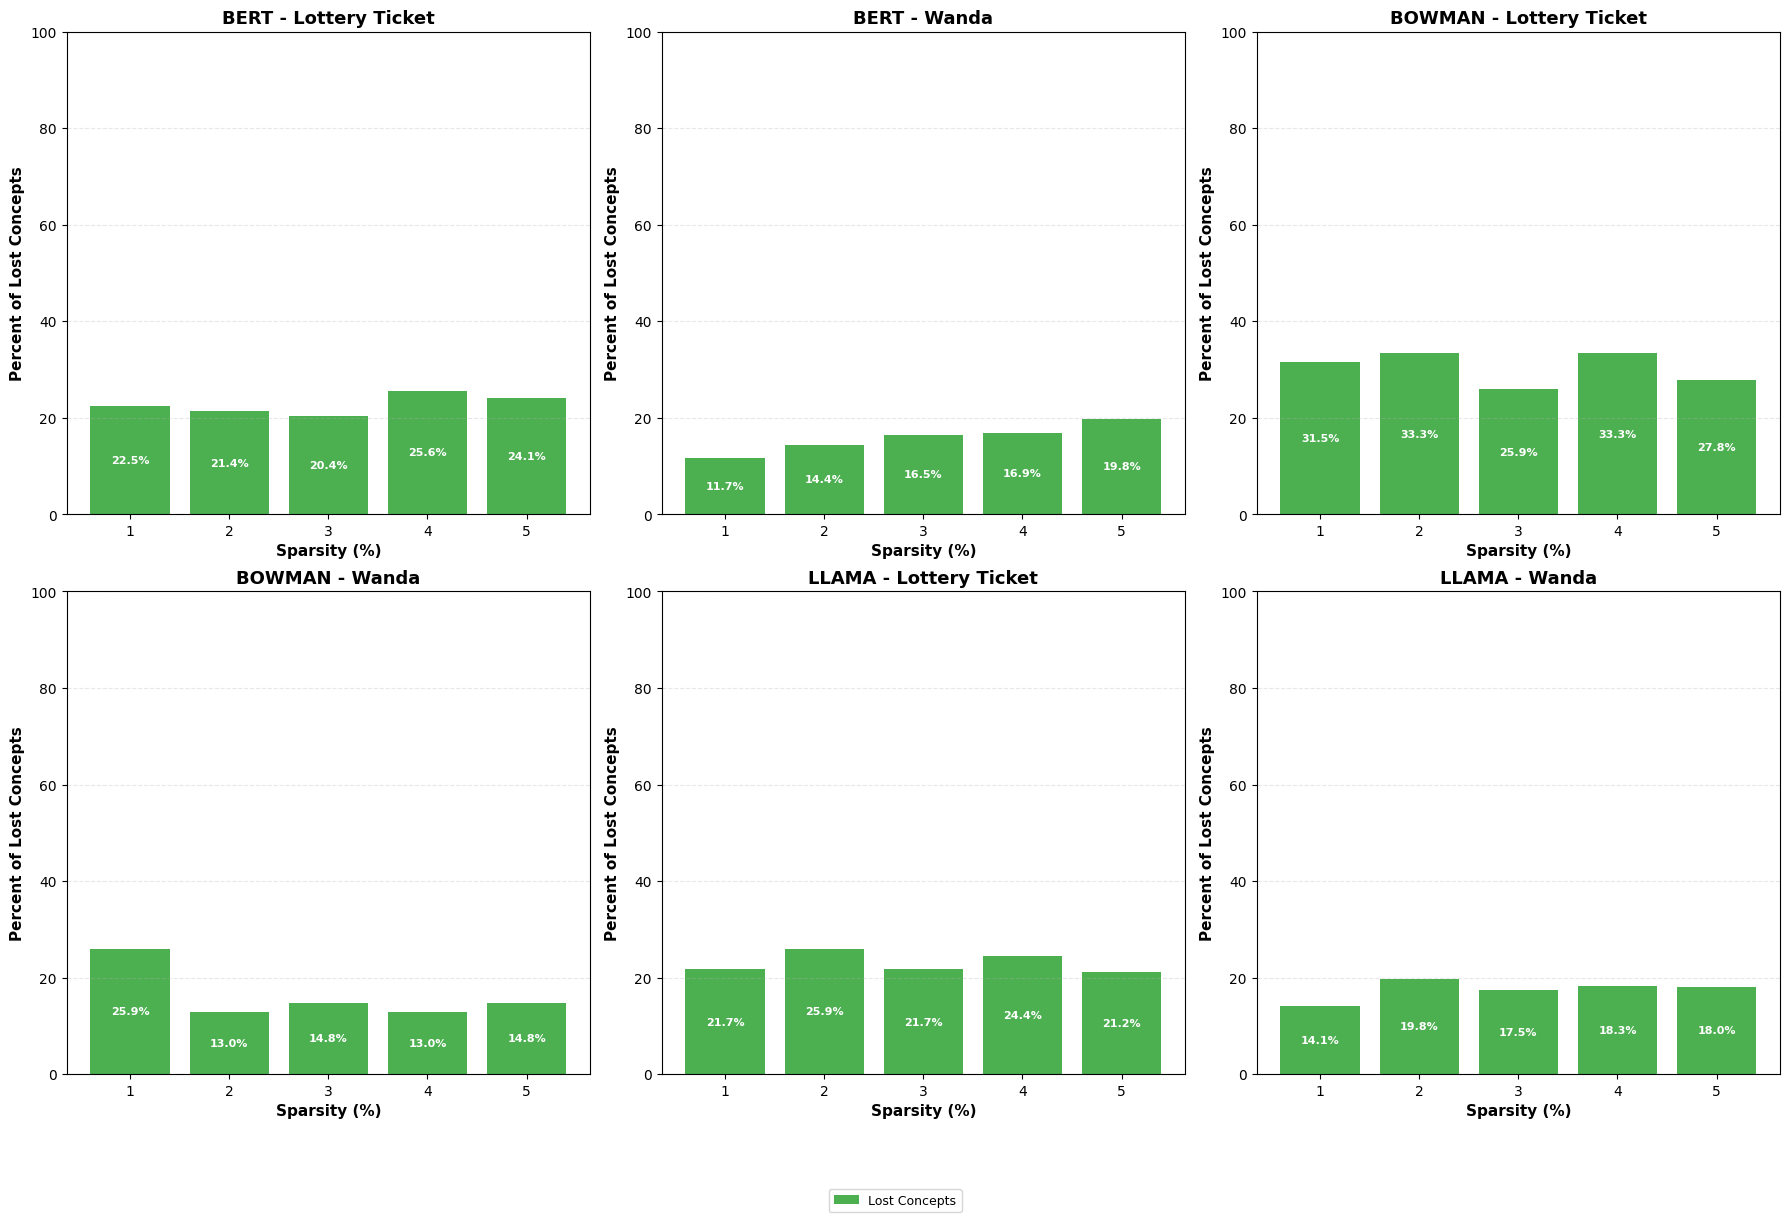

{'BERT': {'lottery_ticket': {'Cluster1': [{'iteration': 1, 'pruning_pct': 25.0, 'total_concepts_baseline': 133, 'total_concepts_curr': 135, 'new_concepts': 34, 'pct_new': 25.185185185185183, 'stayed_same': 31, 'pct_stayed_same': 22.962962962962962, 'moved_to_new_unit': 70, 'pct_moved_to_new': 51.85185185185185, 'disappeared_concepts': 32}, {'iteration': 2, 'pruning_pct': 43.75, 'total_concepts_baseline': 133, 'total_concepts_curr': 132, 'new_concepts': 29, 'pct_new': 21.96969696969697, 'stayed_same': 25, 'pct_stayed_same': 18.939393939393938, 'moved_to_new_unit': 78, 'pct_moved_to_new': 59.09090909090909, 'disappeared_concepts': 30}, {'iteration': 3, 'pruning_pct': 57.812, 'total_concepts_baseline': 133, 'total_concepts_curr': 134, 'new_concepts': 28, 'pct_new': 20.8955223880597, 'stayed_same': 27, 'pct_stayed_same': 20.149253731343283, 'moved_to_new_unit': 79, 'pct_moved_to_new': 58.95522388059702, 'disappeared_concepts': 27}, {'iteration': 4, 'pruning_pct': 68.359, 'total_concepts_ba

In [111]:
import pandas as pd
import re
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

pi = {0: 0.0, 1: 25.0, 2: 43.75, 3: 57.812, 4: 68.359, 5: 76.27}

def get_indiv_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', formula)
    for c in concps:
        try:
            end_idx = c.index(')')
        except:
            end_idx = len(c)
        concepts.append(c[:end_idx])
    return concepts


def load_csv_data(filepath):
    """Load CSV and extract unit-concept mappings."""
    df = pd.read_csv(filepath)
    unit_concepts = defaultdict(set)
    
    for _, row in df.iterrows():
        unit = row['unit']
        formula = row['best_name']
        concepts = get_indiv_concepts(formula)
        unit_concepts[unit].update(concepts)
    
    return unit_concepts


def build_concept_to_units_mapping(unit_concepts_dict):
    """Build a mapping from concepts to all units that explain them."""
    concept_to_units = defaultdict(set)
    for unit, concepts in unit_concepts_dict.items():
        for concept in concepts:
            concept_to_units[concept].add(unit)
    return dict(concept_to_units)


def analyze_concept_migration(base_dir, num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """
    Analyze concept migration across pruning iterations for each cluster.
    All comparisons are made relative to iteration 0 (baseline).
    """
    results = {}
    
    for cluster in clusters:
        print(f"\nAnalyzing {cluster}")
        
        # Track concept-unit mappings across iterations
        iteration_data = []
        
        # Load data for all iterations
        for iteration in range(0, num_iterations + 1):
            csv_path = Path(base_dir) / f"{pi[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            
            if not csv_path.exists():
                print(f"Warning: {csv_path} not found, skipping...")
                continue
            
            unit_concepts = load_csv_data(csv_path)
            concept_to_units = build_concept_to_units_mapping(unit_concepts)
            
            iteration_data.append({
                'iteration': iteration,
                'unit_concepts': unit_concepts,
                'concept_to_units': concept_to_units,
                'all_concepts': set(concept_to_units.keys())
            })
        
        if len(iteration_data) == 0:
            print(f"No data found for {cluster}")
            continue
        
        # Get baseline (iteration 0)
        baseline = iteration_data[0]
        baseline_concepts = baseline['all_concepts']
        baseline_concept_to_units = baseline['concept_to_units']
        
        # Analyze each iteration compared to baseline
        cluster_results = []
        
        for i in range(1, len(iteration_data)):
            curr_iter = iteration_data[i]
            curr_concepts = curr_iter['all_concepts']
            curr_concept_to_units = curr_iter['concept_to_units']
            
            # Calculate metrics relative to baseline
            new_concepts = curr_concepts - baseline_concepts
            disappeared_concepts = baseline_concepts - curr_concepts
            common_concepts = baseline_concepts & curr_concepts
            
            # For common concepts, check overlap of units
            stayed_same = set()
            moved_to_new = set()
            
            for concept in common_concepts:
                baseline_units = baseline_concept_to_units[concept]
                curr_units = curr_concept_to_units[concept]
                
                if baseline_units & curr_units:
                    stayed_same.add(concept)
                else:
                    moved_to_new.add(concept)
            
            # Calculate percentages
            total_curr = len(curr_concepts)
            
            if total_curr > 0:
                pct_new = (len(new_concepts) / total_curr) * 100
                pct_stayed = (len(stayed_same) / total_curr) * 100
                pct_moved = (len(moved_to_new) / total_curr) * 100
            else:
                pct_new = pct_stayed = pct_moved = 0
            
            result = {
                'iteration': curr_iter['iteration'],
                'pruning_pct': pi[curr_iter['iteration']],
                'total_concepts_baseline': len(baseline_concepts),
                'total_concepts_curr': total_curr,
                'new_concepts': len(new_concepts),
                'pct_new': pct_new,
                'stayed_same': len(stayed_same),
                'pct_stayed_same': pct_stayed,
                'moved_to_new_unit': len(moved_to_new),
                'pct_moved_to_new': pct_moved,
                'disappeared_concepts': len(disappeared_concepts)
            }
            
            cluster_results.append(result)
        
        results[cluster] = cluster_results
    
    return results


def analyze_cross_cluster_migration(base_dir, num_iterations=5, clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """Analyze concept migration across neurons and clusters."""
    
    # Load baseline (iteration 0) for all clusters
    baseline_cluster_data = {}
    baseline_concept_map = defaultdict(lambda: defaultdict(set))
    
    for cluster in clusters:
        csv_path = Path(base_dir) / f"{pi[0]}%Pruned" / f"{cluster}IOUS1024N.csv"
        if not csv_path.exists():
            continue
        
        unit_concepts = load_csv_data(csv_path)
        baseline_cluster_data[cluster] = unit_concepts
        
        for unit, concepts in unit_concepts.items():
            for concept in concepts:
                baseline_concept_map[concept][cluster].add(unit)
    
    all_baseline_concepts = set(baseline_concept_map.keys())
    migration_results = []
    
    for iteration in range(1, num_iterations + 1):
        current_cluster_data = {}
        current_concept_map = defaultdict(lambda: defaultdict(set))
        
        for cluster in clusters:
            csv_path = Path(base_dir) / f"{pi[iteration]}%Pruned" / f"{cluster}IOUS1024N.csv"
            if not csv_path.exists():
                continue
            
            unit_concepts = load_csv_data(csv_path)
            current_cluster_data[cluster] = unit_concepts
            
            for unit, concepts in unit_concepts.items():
                for concept in concepts:
                    current_concept_map[concept][cluster].add(unit)
        
        all_current_concepts = set(current_concept_map.keys())
        
        # Categorize concepts
        same_neuron_same_cluster = set()
        same_neuron_diff_cluster = set()
        diff_neuron_same_cluster = set()
        diff_neuron_diff_cluster = set()
        new_concepts = all_current_concepts - all_baseline_concepts
        disappeared_concepts = all_baseline_concepts - all_current_concepts
        
        common_concepts = all_baseline_concepts & all_current_concepts
        
        for concept in common_concepts:
            baseline_clusters = baseline_concept_map[concept]
            current_clusters = current_concept_map[concept]
            
            # Check if concept stayed in exact same locations
            has_exact_match = False
            for cluster in baseline_clusters:
                if cluster in current_clusters:
                    if baseline_clusters[cluster] & current_clusters[cluster]:
                        has_exact_match = True
                        break
            
            if has_exact_match:
                same_neuron_same_cluster.add(concept)
                continue
            
            # Check for cross-cluster neuron migration
            cross_cluster_migration = False
            
            for orig_cluster in baseline_clusters:
                baseline_units = baseline_clusters[orig_cluster]
                
                for other_cluster in current_clusters:
                    if other_cluster == orig_cluster:
                        continue
                    
                    current_units = current_clusters[other_cluster]
                    
                    for unit in baseline_units:
                        if unit in current_units and unit not in baseline_concept_map[concept].get(other_cluster, set()):
                            cross_cluster_migration = True
                            break
                    
                    if cross_cluster_migration:
                        break
                
                if cross_cluster_migration:
                    break
            
            if cross_cluster_migration:
                same_neuron_diff_cluster.add(concept)
                continue
            
            # Check if concept stayed in same cluster(s) but with different neurons
            has_same_cluster = False
            for cluster in baseline_clusters:
                if cluster in current_clusters:
                    has_same_cluster = True
                    break
            
            if has_same_cluster:
                diff_neuron_same_cluster.add(concept)
            else:
                diff_neuron_diff_cluster.add(concept)
        
        # Calculate counts and percentages
        total_baseline = len(all_baseline_concepts)
        total_current = len(all_current_concepts)
        
        result = {
            'iteration': iteration,
            'pruning_pct': pi[iteration],
            'total_baseline_concepts': total_baseline,
            'total_current_concepts': total_current,
            'same_neuron_same_cluster': len(same_neuron_same_cluster),
            'same_neuron_diff_cluster': len(same_neuron_diff_cluster),
            'diff_neuron_same_cluster': len(diff_neuron_same_cluster),
            'diff_neuron_diff_cluster': len(diff_neuron_diff_cluster),
            'new_concepts': len(new_concepts),
            'disappeared_concepts': len(disappeared_concepts),
        }
        
        
        
        # Add percentages
        if total_current > 0:
            result['pct_same_neuron_same_cluster'] = (len(same_neuron_same_cluster) / total_current) * 100
            result['pct_same_neuron_diff_cluster'] = (len(same_neuron_diff_cluster) / total_current) * 100
            result['pct_diff_neuron_same_cluster'] = (len(diff_neuron_same_cluster) / total_current) * 100
            result['pct_diff_neuron_diff_cluster'] = (len(diff_neuron_diff_cluster) / total_current) * 100
            result['pct_new_concepts'] = (len(new_concepts) / total_current) * 100
            result['lost_concepts']=(result['disappeared_concepts']/len(all_baseline_concepts)) *100
        else:
            result['pct_same_neuron_same_cluster'] = 0
            result['pct_same_neuron_diff_cluster'] = 0
            result['pct_diff_neuron_same_cluster'] = 0
            result['pct_diff_neuron_diff_cluster'] = 0
            result['pct_new_concepts'] = 0
        
        migration_results.append(result)
        
        '''print(f"Iteration: {result['iteration']}\n{result['pruning_pct']}% Sparse")
        print(f"% Same neuron same cluster: {result['pct_same_neuron_same_cluster']}")
        print(f"% Same neuron different cluster: {result['pct_same_neuron_diff_cluster']}")
        print(f"% Different neuron same cluster: {result['pct_diff_neuron_same_cluster']}")
        print(f"% New concepts: {result['pct_new_concepts']}")
        print(f"% Lost concepts: {result['disappeared_concepts']/len(all_baseline_concepts)}")'''
    
    return migration_results


def analyze_all_models_methods(base_path_template, models, methods, run='Run0.25'):
    """
    Analyze all model-method combinations for both per-cluster and cross-cluster migration.
    
    Returns:
        {
            'per_cluster': {model: {method: results}},
            'cross_cluster': {model: {method: migration_results}}
        }
    """
    per_cluster_results = {}
    cross_cluster_results = {}
    
    for model in models:
        per_cluster_results[model] = {}
        cross_cluster_results[model] = {}
        
        for method in methods:
            print(f"\n{'='*80}")
            print(f"Processing: {model} - {method}")
            print(f"{'='*80}")
            
            # Construct path
            base_dir = base_path_template.format(model=model.upper(), method=method, run=run)
            
            # Check if directory exists
            if not Path(base_dir).exists():
                print(f"Warning: Directory not found: {base_dir}")
                per_cluster_results[model][method] = None
                cross_cluster_results[model][method] = None
                continue
            
            # Run analyses
            try:
                print("Running per-cluster analysis...")
                per_cluster = analyze_concept_migration(base_dir)
                per_cluster_results[model][method] = per_cluster
                
                print("Running cross-cluster analysis...")
                cross_cluster = analyze_cross_cluster_migration(base_dir)
                cross_cluster_results[model][method] = cross_cluster
                
                print(f"✓ Successfully analyzed {model} - {method}")
            except Exception as e:
                print(f"✗ Error analyzing {model} - {method}: {e}")
                per_cluster_results[model][method] = None
                cross_cluster_results[model][method] = None
    
    return {
        'per_cluster': per_cluster_results,
        'cross_cluster': cross_cluster_results
    }


def plot_multi_model_concept_migration(per_cluster_results, models, methods, 
                                       save_path='multi_model_concept_migration.png',
                                       clusters=['Cluster1', 'Cluster2', 'Cluster3']):
    """
    Create subplots for concept migration (per-cluster analysis).
    Each subplot shows one model-method combination for ONE specific cluster.
    Creates separate plots for each cluster.
    """
    for cluster in clusters:
        valid_combos = []
        for model in models:
            for method in methods:
                if per_cluster_results.get(model, {}).get(method) is not None:
                    if cluster in per_cluster_results[model][method]:
                        valid_combos.append((model, method))
        
        if not valid_combos:
            print(f"No valid per-cluster results to plot for {cluster}!")
            continue
        
        num_combos = len(valid_combos)
        ncols = min(3, num_combos)
        nrows = (num_combos + ncols - 1) // ncols
        
        fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
        
        if num_combos == 1:
            axes = np.array([axes])
        axes = axes.flatten() if num_combos > 1 else axes
        
        for idx, (model, method) in enumerate(valid_combos):
            ax = axes[idx]
            cluster_results = per_cluster_results[model][method][cluster]
            
            # Extract data for this cluster
            iterations = [r['iteration'] for r in cluster_results]
            pct_new = [r['pct_new'] for r in cluster_results]
            pct_stayed = [r['pct_stayed_same'] for r in cluster_results]
            pct_moved = [r['pct_moved_to_new'] for r in cluster_results]
            
            # Create stacked bar chart
            x = np.arange(len(iterations))
            
            p1 = ax.bar(x, pct_stayed, label='Stayed Same Unit', color='#2196F3')
            p2 = ax.bar(x, pct_moved, bottom=pct_stayed, label='Moved to New Unit', color='#FF9800')
            p3 = ax.bar(x, pct_new, bottom=np.array(pct_stayed)+np.array(pct_moved), 
                       label='New Concepts', color='#4CAF50')
            
            # Add percentage labels
            for i in range(len(iterations)):
                if pct_stayed[i] > 5:
                    ax.text(i, pct_stayed[i]/2, f'{pct_stayed[i]:.1f}%',
                           ha='center', va='center', fontsize=8, fontweight='bold', color='white')
                if pct_moved[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i]/2, f'{pct_moved[i]:.1f}%',
                           ha='center', va='center', fontsize=8, fontweight='bold', color='white')
                if pct_new[i] > 5:
                    ax.text(i, pct_stayed[i] + pct_moved[i] + pct_new[i]/2, f'{pct_new[i]:.1f}%',
                           ha='center', va='center', fontsize=8, fontweight='bold', color='white')
            
            # Customize subplot
            ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
            ax.set_ylabel('Percent of Concepts', fontsize=11, fontweight='bold')
            ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                         fontsize=13, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels([f'{pi[it]:.0f}' for it in iterations])
            ax.grid(axis='y', alpha=0.3, linestyle='--')
            ax.set_ylim(0, 100)
        
        # Hide empty subplots
        for idx in range(num_combos, len(axes)):
            axes[idx].axis('off')
        
        # Add shared legend
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10,
                   bbox_to_anchor=(0.5, -0.02), frameon=True)
        
        # Add main title for the cluster
        fig.suptitle(f'Concept Migration - {cluster}', fontsize=16, fontweight='bold', y=1.0)
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.08, top=0.95)
        
        # Save with cluster name
        cluster_save_path = save_path.replace('.png', f'_{cluster}.png')
        plt.savefig(cluster_save_path, dpi=300, bbox_inches='tight')
        print(f"\nConcept migration plot for {cluster} saved to '{cluster_save_path}'")
        plt.show()
def plot_lost_concepts(per_iteration_results, models, methods, 
                                       save_path='lost_concepts.png',
                                       pi=5):
    """
    Create subplots for concept migration (per-cluster analysis).
    Each subplot shows one model-method combination for ONE specific cluster.
    Creates separate plots for each cluster.
    """
    valid_combos = []
    for model in models:
        for method in methods:
            if per_iteration_results.get(model, {}).get(method) is not None:
                valid_combos.append((model, method))
    
    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return
    
    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
    
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes
    
    colors = {
        'same_neuron_same_cluster': '#4CAF50',
        'same_neuron_diff_cluster': '#2196F3',
        'diff_neuron_same_cluster': '#FF9800',
        'diff_neuron_diff_cluster': '#F44336',
        'new_concepts': '#9C27B0'
    }
    
    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = per_iteration_results[model][method]
        
        # Extract data
        lost_concepts = [r['lost_concepts'] for r in migration_results]
        
        x = np.arange(len(migration_results))
        
        # Create stacked bars
        p1 = ax.bar(x, lost_concepts, label='Lost Concepts', 
                    color=colors['same_neuron_same_cluster'])
       
        for bars in [p1]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2.,
                            height / 2,
                            f'{height:.1f}%',
                            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        
        # Customize subplot
        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Lost Concepts', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                     fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{r["iteration"]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)
    
    # Hide empty subplots
    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')
    
    # Add shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nLost concepr plot saved to '{save_path}'")
    plt.show()



def plot_multi_model_cross_cluster_migration(cross_cluster_results, models, methods,
                                             save_path='multi_model_cross_cluster_migration.png'):
    """
    Create subplots for cross-cluster migration analysis.
    Each subplot shows one model-method combination.
    """
    valid_combos = []
    for model in models:
        for method in methods:
            if cross_cluster_results.get(model, {}).get(method) is not None:
                valid_combos.append((model, method))
    
    if not valid_combos:
        print("No valid cross-cluster results to plot!")
        return
    
    num_combos = len(valid_combos)
    ncols = min(3, num_combos)
    nrows = (num_combos + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
    
    if num_combos == 1:
        axes = np.array([axes])
    axes = axes.flatten() if num_combos > 1 else axes
    
    colors = {
        'same_neuron_same_cluster': '#4CAF50',
        'same_neuron_diff_cluster': '#2196F3',
        'diff_neuron_same_cluster': '#FF9800',
        'diff_neuron_diff_cluster': '#F44336',
        'new_concepts': '#9C27B0'
    }
    
    for idx, (model, method) in enumerate(valid_combos):
        ax = axes[idx]
        migration_results = cross_cluster_results[model][method]
        
        # Extract data
        same_n_same_c = [r['pct_same_neuron_same_cluster'] for r in migration_results]
        same_n_diff_c = [r['pct_same_neuron_diff_cluster'] for r in migration_results]
        diff_n_same_c = [r['pct_diff_neuron_same_cluster'] for r in migration_results]
        diff_n_diff_c = [r['pct_diff_neuron_diff_cluster'] for r in migration_results]
        new_concepts = [r['pct_new_concepts'] for r in migration_results]
        
        x = np.arange(len(migration_results))
        
        # Create stacked bars
        p1 = ax.bar(x, same_n_same_c, label='Same Neuron, Same Cluster', 
                    color=colors['same_neuron_same_cluster'])
        p2 = ax.bar(x, same_n_diff_c, bottom=same_n_same_c,
                    label='Same Neuron, Diff Cluster', 
                    color=colors['same_neuron_diff_cluster'])
        p3 = ax.bar(x, diff_n_same_c,
                    bottom=np.array(same_n_same_c) + np.array(same_n_diff_c),
                    label='Diff Neuron, Same Cluster', 
                    color=colors['diff_neuron_same_cluster'])
        p4 = ax.bar(x, diff_n_diff_c,
                    bottom=np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c),
                    label='Diff Neuron, Diff Cluster', 
                    color=colors['diff_neuron_diff_cluster'])
        p5 = ax.bar(x, new_concepts,
                    bottom=np.array(same_n_same_c) + np.array(same_n_diff_c) + 
                           np.array(diff_n_same_c) + np.array(diff_n_diff_c),
                    label='New Concepts', 
                    color=colors['new_concepts'])
        
        # Add value labels
        bar_containers = [p1, p2, p3, p4, p5]
        bottoms = [
            np.zeros(len(x)),
            np.array(same_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + np.array(diff_n_same_c),
            np.array(same_n_same_c) + np.array(same_n_diff_c) + 
            np.array(diff_n_same_c) + np.array(diff_n_diff_c)
        ]
        
        for bars, bottom in zip(bar_containers, bottoms):
            for bar, base in zip(bars, bottom):
                height = bar.get_height()
                if height > 3:
                    ax.text(bar.get_x() + bar.get_width() / 2.,
                            base + height / 2,
                            f'{height:.1f}%',
                            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        
        # Customize subplot
        ax.set_xlabel('Sparsity (%)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Percent of Concepts', fontsize=11, fontweight='bold')
        ax.set_title(f'{model.upper()} - {method.replace("_", " ").title()}', 
                     fontsize=13, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{pi[r["iteration"]]:.0f}' for r in migration_results])
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 100)
    
    # Hide empty subplots
    for idx in range(num_combos, len(axes)):
        axes[idx].axis('off')
    
    # Add shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
               bbox_to_anchor=(0.5, -0.02), frameon=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\nCross-cluster migration plot saved to '{save_path}'")
    plt.show()


# Example usage
if __name__ == "__main__":
    # Configuration
    models = ['BERT', 'BOWMAN', 'LLAMA']
    methods = ['lottery_ticket', 'wanda']
    run = 'Run0.25'
    base_path_template = "/workspace/CCE_NLI/{model}/exp/{method}/{run}/Expls/"
    
    # Analyze all combinations
    print("="*80)
    print("MULTI-MODEL MIGRATION ANALYSIS")
    print("="*80)
    
    all_results = analyze_all_models_methods(
        base_path_template=base_path_template,
        models=models,
        methods=methods,
        run=run
    )
    
    # Plot per-cluster concept migration
    '''print("\n" + "="*80)
    print("GENERATING PER-CLUSTER CONCEPT MIGRATION PLOTS")
    print("="*80)
    plot_multi_model_concept_migration(
        per_cluster_results=all_results['per_cluster'],
        models=models,
        methods=methods,
        save_path='multi_model_concept_migration.png'
    )'''
    
    # Plot cross-cluster migration
    '''print("\n" + "="*80)
    print("GENERATING CROSS-CLUSTER MIGRATION PLOTS")
    print("="*80)
    plot_multi_model_cross_cluster_migration(
        cross_cluster_results=all_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='multi_model_cross_cluster_migration.png'
    )'''
    plot_lost_concepts(per_iteration_results=all_results['cross_cluster'],
        models=models,
        methods=methods,
        save_path='lost_concepts.png',
        pi=5)
    print(all_results['per_cluster'])
    print("\n" + "="*80)
    print("Analysis complete!")
    print("="*80)

In [2]:
pi={0:0.0, 1:25.0, 2:43.75, 3:57.812, 4:68.359, 5:76.27}

In [41]:
title = 'bert/lth'
#root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp/Expls"
import collections
concepts=get_collected_concepts(root)
def count_neuron_cluster_shifts(og, pruned):
    """
    Counts how many neurons were assigned to a different cluster in pruned compared to og.
    Only neurons that exist in both og and pruned are considered.
    """
    # Build reverse maps: neuron -> cluster
    og_map = collections.defaultdict(list)
    pruned_map = collections.defaultdict(list)

    for cluster_name, neurons in og.items():
        for n in neurons:
            og_map[n].append(cluster_name)

    for cluster_name, neurons in pruned.items():
        for n in neurons:
            pruned_map[n].append(cluster_name)

    # Count neurons that are in both and switched clusters
    moved = 0
    for neuron in og_map:
        if neuron in pruned_map:
            for cluster in pruned_map[neuron]:
                if cluster not in og_map[neuron]:
                    moved += 1
                    break

    return moved

        
        
def count_func_tok(shifts):
    '''
        Counts number of functional and token conceots at each pruning iter and number of neurons that shift
        ex: if 0 neurons shift at 20% pruning for 5 concepts of which 2 are functional and 3 are tokens, 
        for prune_iter 20%, # of shifting neurons 0, it will return 2 functional, 3 tokens
    '''
    f_c = ['and', 'or', 'in', 'a', 'of', 'it', 'at', 'for', 'from', 'by']
    news=collections.defaultdict(lambda: collections.defaultdict(lambda: {'functional': 0, 'token': 0}))
    for c in shifts:
        for p, v in shifts[c].items():
            if v not in news[p]:
                if ':tag:' in c or ':overlap:' in c or c in f_c:
                    news[p][v]['functional'] =  1
                else:
                    news[p][v]['token'] = 1
            else:
                if ':tag:' in c or ':overlap:' in c or c in f_c:
                    news[p][v]['functional'] += 1
                else:
                    news[p][v]['token'] += 1
    return news

def shift(concepts):  
    prune_percents = get_all_pruned_iters(concepts)
    '''
        Takes the concetp dict and returns the ratio between functional and token concepts
        in the context of neurons shifting across clusters between iterations 
        note: this means that if a concept is explain by neuron 5 in cluster 1, then after pruning, neuron 5 is explaining
        the concept, but in cluster 3, then neuron 5 is "shifted"
        
        
    '''
    this is the pseudocode
    concepts should look like  
        concepts= {0%: 
               {concept1: {c1: [neirns ], c2:[neurons], c3: [neurons]}, 
                concept2: ... }, 
               25%: }
    '''def shfitedneuronsexite(orignal, pruned):
        if c1 neurons exist in c2/c3 return true
        if c2 neurons exist in c1/c2 return true
        if c3 neurons exist in c1/c2 return true
        else return false
   
    shifts = collections.defaultdict(dict)
    for each pruning iter
        #how many concepts are shifted from the original / totla num concepts in pruned 
        for each concept
            if shifted neurons exist --> shfited_neurons_exist(concepts[0%][concept] concepts[pruned%][concept])
                count += 1
        results[pruningiter] = count / num_concepts_in_pruned (get indiv concepts func call)'''
    grpah results
        
    for concept in concepts.keys():

        originally_active_neurons = getActiveNeurons(concepts[concept], '0.0% Prune')

        if not originally_active_neurons: continue

        for pi in prune_percents:
       
            if pi == '0.0% Prune': continue
            neurons_active_at_pi = getActiveNeurons(concepts[concept], pi)
            if not neurons_active_at_pi: continue 
            
            shifts[concept][pi] = count_neuron_cluster_shifts(originally_active_neurons, neurons_active_at_pi)
    counts = count_func_tok(shifts)
    print(shifts)

    
    for p in counts:
        for neur in counts[p]:
            funcc = counts[p][neur]['functional'] 
            tokk = counts[p][neur]['token'] 
            counts[p][neur]['functional']  /= (funcc+tokk)
            counts[p][neur]['token']  /= (funcc+tokk)
    return counts
shift(concepts)



defaultdict(<class 'dict'>, {'NOT hyp:tok:to': {'25.0% Prune': 0, '43.75% Prune': 0, '57.812% Prune': 0, '68.359% Prune': 0, '76.27% Prune': 0}, 'hyp:tok:running': {'25.0% Prune': 0, '43.75% Prune': 0, '57.812% Prune': 0, '76.27% Prune': 0}, 'oth:overlap:overlap75': {'25.0% Prune': 0, '43.75% Prune': 0, '57.812% Prune': 0, '68.359% Prune': 0, '76.27% Prune': 0}, 'NOT hyp:tok:outside': {'25.0% Prune': 0, '43.75% Prune': 0, '57.812% Prune': 0, '68.359% Prune': 0, '76.27% Prune': 0}, 'hyp:tok:bowling': {'68.359% Prune': 0}, 'NOT hyp:tag:in': {'25.0% Prune': 0, '43.75% Prune': 0, '57.812% Prune': 0, '68.359% Prune': 0}, 'hyp:tag:dt': {'43.75% Prune': 0, '57.812% Prune': 0, '68.359% Prune': 0, '76.27% Prune': 0}, 'NOT oth:overlap:overlap50': {'25.0% Prune': 0, '43.75% Prune': 0, '57.812% Prune': 0, '68.359% Prune': 0, '76.27% Prune': 0}, 'NOT hyp:tok:playing': {'76.27% Prune': 0}, 'hyp:tok:to': {'25.0% Prune': 0, '43.75% Prune': 0, '57.812% Prune': 0, '68.359% Prune': 0, '76.27% Prune': 0},

defaultdict(<function __main__.count_func_tok.<locals>.<lambda>()>,
            {'25.0% Prune': defaultdict(<function __main__.count_func_tok.<locals>.<lambda>.<locals>.<lambda>()>,
                         {0: {'functional': 0.4, 'token': 0.6}}),
             '43.75% Prune': defaultdict(<function __main__.count_func_tok.<locals>.<lambda>.<locals>.<lambda>()>,
                         {0: {'functional': 0.39622641509433965,
                           'token': 0.6037735849056604},
                          1: {'functional': 0.0, 'token': 1.0}}),
             '57.812% Prune': defaultdict(<function __main__.count_func_tok.<locals>.<lambda>.<locals>.<lambda>()>,
                         {0: {'functional': 0.3793103448275862,
                           'token': 0.6206896551724138}}),
             '68.359% Prune': defaultdict(<function __main__.count_func_tok.<locals>.<lambda>.<locals>.<lambda>()>,
                         {0: {'functional': 0.38596491228070173,
                           't

In [16]:

    
def shift(concepts):  
    prune_percents = get_all_pruned_iters(concepts)
    '''
        Takes the concetp dict and returns the ratio between functional and token concepts
        in the context of neurons shifting across clusters between iterations 
        note: this means that if a concept is explain by neuron 5 in cluster 1, then after pruning, neuron 5 is explaining
        the concept, but in cluster 3, then neuron 5 is "shifted"
    '''
    shifts = collections.defaultdict(dict)
    for concept in concepts.keys():

        originally_active_neurons = getActiveNeurons(concepts[concept], '0.0% Prune')
        
        if not originally_active_neurons: continue

        for pi in prune_percents:
            if pi == '0.0% Prune': continue
            neurons_active_at_pi = getActiveNeurons(concepts[concept], pi)
            if not neurons_active_at_pi: continue 
            shifts[concept][pi] = count_shifts(originally_active_neurons, neurons_active_at_pi)
           
    counts = count_func_tok(shifts)
    
    for p in counts:
        for neur in counts[p]:
            funcc = counts[p][neur]['functional'] 
            tokk = counts[p][neur]['token'] 
            counts[p][neur]['functional']  /= (funcc+tokk)
            counts[p][neur]['token']  /= (funcc+tokk)
    return counts

def count_func_tok(shifts):
    '''
        Counts number of functional and token conceots at each pruning iter and number of neurons that shift
        ex: if 0 neurons shift at 20% pruning for 5 concepts of which 2 are functional and 3 are tokens, 
        for prune_iter 20%, # of shifting neurons 0, it will return 2 functional, 3 tokens
    '''
    news=collections.defaultdict(lambda: collections.defaultdict(lambda: {'functional': 0, 'token': 0}))
    for c in shifts:
        for p, v in shifts[c].items():
            if v not in news[p]:
                if ':tag:' in c or ':overlap:' in c or c in f_c:
                    news[p][v]['functional'] =  1
                else:
                    news[p][v]['token'] = 1
            else:
                if ':tag:' in c or ':overlap:' in c or c in f_c:
                    news[p][v]['functional'] += 1
                else:
                    news[p][v]['token'] += 1
    return news
# these tell you what percent of concepts where x neurons shift from orig are func or token
# shift doesnt mean lost, it just means moving clusters. so a iteration can have 0 shifted neurons but all neurons from orig are lost
title = 'bert/wanda'
root="bert/wanda/Run2FIXEDLTH/Expls"
concepts=get_collected_concepts(root)
shift_rates = shift(concepts)  #on avg 0.35 neurons shift at 73% pruning
graph_neuron_shift(shift_rates, "Bert Wanda") #neurons move for functional concepts not so much for token 
    #explaing: ex: 19%,  82.9% of the concepts where there is no neuron shifting are token
    #all concepts where 2 neurons shift in 19% are functinoal (overlpa, tags,in,and,etc)
    
title = 'bowman/wanda'
root="bowman/wanda/RunBowmanWandaReformatted/Expls"
concepts=get_collected_concepts(root)
shift_rates = shift(concepts)  #on avg 0.35 neurons shift at 73% pruning
graph_neuron_shift(shift_rates, "Bowman Wanda") #neurons move for functional concepts not so much for token 
    #explaing: ex: 19%,  82.9% of the concepts where there is no neuron shifting are token
    #all concepts where 2 neurons shift in 19% are functinoal (overlpa, tags,in,and,etc)
    
title = 'bert/lottery_ticket'
root="bert/lottery_ticket/RunBERT_LTHFIXED/Expls/"
concepts=get_collected_concepts(root)
shift_rates = shift(concepts)  #on avg 0.35 neurons shift at 73% pruning
graph_neuron_shift(shift_rates, "Lottery Ticket Bert") #neurons move for functional concepts not so much for token 
    #explaing: ex: 19%,  82.9% of the concepts where there is no neuron shifting are token
    #all concepts where 2 neurons shift in 19% are functinoal (overlpa, tags,in,and,etc)
    
title = 'bowman/lottery_ticket'
root="bowman/lottery_ticket/Run2FIXEDLTH/Expls"
concepts=get_collected_concepts(root)
shift_rates = shift(concepts)  #on avg 0.35 neurons shift at 73% pruning
graph_neuron_shift(shift_rates, "Lottery Ticket Bowman") #neurons move for functional concepts not so much for token 
    #explaing: ex: 19%,  82.9% of the concepts where there is no neuron shifting are token
    #all concepts where 2 neurons shift in 19% are functinoal (overlpa, tags,in,and,etc)
    
#finding: for bert the concepts that shift more neurons are functional, token shift fewer (but they still might be lost more)
#do this per concept as well (mean, kl div, median, other stats to show the shift)

FileNotFoundError: [Errno 2] No such file or directory: 'bert/wanda/Run2FIXEDLTH/Expls'

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import re
from collections import defaultdict
def graph_neuron_shift(raw_data, title):
    prune_percentages = sorted(raw_data.keys(), 
                              key=lambda x: float(re.search(r'(\d+\.\d+)', x).group(1)))

    # Create a figure with subplots
    fig, axes = plt.subplots(5,3, figsize=(15, 10))
    axes = axes.flatten()

    colors = {'functional': '#1f77b4', 'token': '#ff7f0e'}

    # Plot each prune percentage as a separate subplot
    for i, prune_pct in enumerate(prune_percentages):
        shift_counts = sorted(raw_data[prune_pct].keys())
        functional_values = [raw_data[prune_pct][count]['functional'] * 100 for count in shift_counts]
        token_values = [raw_data[prune_pct][count]['token'] * 100 for count in shift_counts]

        ax = axes[i]
        width = 0.8

        # Create stacked bar chart
        ax.bar(shift_counts, functional_values, width, label='Functional', color=colors['functional'])
        ax.bar(shift_counts, token_values, width, bottom=functional_values, 
               label='Token', color=colors['token'])

        # Add labels and formatting
        ax.set_title(f'{prune_pct}')
        ax.set_xlabel('Neuron Shift Count')
        ax.set_ylabel('Percentage (%)')
        ax.set_xticks(shift_counts)
        ax.set_ylim(0, 100)

        # Add percentage labels on bars
        for j, count in enumerate(shift_counts):
            # Only add labels if the segment is visible enough
            if functional_values[j] > 5:
                ax.text(count, functional_values[j]/2, f'{functional_values[j]:.1f}%', 
                       ha='center', va='center', color='white', fontweight='bold')
            if token_values[j] > 5:
                ax.text(count, functional_values[j] + token_values[j]/2, 
                       f'{token_values[j]:.1f}%', ha='center', va='center', 
                       color='white', fontweight='bold')

    # Add a single legend for the entire figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
              ncol=2, fontsize=12)

    # Set an overall title
    fig.suptitle(f'Distribution of Functional vs. Token CPs by Neuron Shift Count and Prune Percentage for {title}', 
                fontsize=16)

    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.savefig('neuron_shift_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()


% of neurons that are explained at the same cluster per pruning iteration

In [13]:
#root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp/Expls"
concepts=get_collected_concepts(root)
f_c= set(["at", "in", "is", "there", "on", "to", "are", "for", "has", "not", "their" ,"is", "while", "and", "by", "with", "from", "are", "one", "no", "another", "this", "these", "that", "those", "my", "our", "your", "his", "her", "its", "their", "some", "any", "every", "other", "many", "more", "most", "enough", "few", "less", "much", "either", "neither", "several", "all", "both", "each", "one", "two", "three", "four", "first", "second", "third" ,"last", "can", "have", "be", "do", "could", "has", "am", "does", "will", "had", "is", "did", "would", "having", "are", "done", "shall", "was", "doing", "should", "were", "may", "been", "might", "being", "must", "but", "or", "yet", "nor", "for", "so", "before", "once", "since", "until", "when", "while", "as", "like",  "although", "though", "whereas", "while", "except", "because", "since", "if", "where", "when", "why", "whom", "whose", "which", "what", "how"])

#take a concept groip(all positive concepts per neuron) then find at each prune iter and cluster how it moves
#make it so that each x has 1 output and you average the outputs
    #ex neuron 1 has 1 output per prn
    
#count % fo pruning iters a neuron in the orig is defined (ex 725 is at 4/13 iters, 275 is at 5/13)
    #(1 per prune iter even if a neuron si activ at more than 1 cluster)
#count how freq neurons migrate
#count how many neurons die from orrig (ex neuron 425 in this case)
#% of neurons that stayed in the same cluster at each iter
    #20% -> 1/3
    #35-> 1/3
    #48: 1/3
    #59: 1/3
    #67: 1/3
    #73: 0/3...
    
    #do this for all concepts, sort by the percent (like 0/3 < 1/3) and graph like a curve you can pinpoint outliers (imagine it possibly being like a bell curve)

def getActiveNeurons(concept_dict, pi):
    pi_str = pi
    if pi_str not in concept_dict.keys(): return None
    neuronspercluster = collections.defaultdict(list)
    concept_dict = concept_dict[pi_str]
    for cluster in ['Cluster1', 'Cluster2', 'Cluster3']:
        if len(concept_dict[cluster]) ==0: 
            neuronspercluster[cluster]=[]
            continue
        for neurons in concept_dict[cluster]:
            neuron = neurons[neurons.index(" ")+1: neurons.index(":")]
            neuronspercluster[cluster].append(neuron)
    return neuronspercluster

def percent_of_neurons_thatStayed_in_same_cluster(original, pruned):
    pcents = collections.defaultdict()
    for cluster in original.keys():
        original[cluster] = torch.tensor(original[cluster]) 
        pruned[cluster] = torch.tensor(pruned[cluster])
        pcents[cluster] = (original[cluster] & pruned[cluster]).sum() / (original[cluster].sum())
    return pcents

def mask(list_):
    masks={}
    for c in list_.keys():
        mask_ = [1 if str(i) in list_[c] else 0 for i in range(1024)]
        masks[c]=mask_

    return masks


def get_concept_counts(consistency):
    concept_counts={}
    for concept in consistency:
        for prune_iters in consistency[concept]:
            for cluster, percent in consistency[concept][prune_iters].items():
                if torch.isnan(percent):
                    continue

                # Initialize the counts dictionary structure if needed
                if cluster not in concept_counts:
                    concept_counts[cluster] = {}
                if prune_iters not in concept_counts[cluster]:
                    concept_counts[cluster][prune_iters] = {'functional': 0, 'token': 0}

                # Increment the appropriate counter
                cp_root=concept[concept.rindex(":")+1:]
                if cp_root in f_c or ':tag:' in cp_root or ':overlap:' in cp_root:
                    concept_counts[cluster][prune_iters]['functional'] += 1
                else:
                    concept_counts[cluster][prune_iters]['token'] += 1
                    
    return concept_counts
prune_percents = get_all_pruned_iters(concepts)
def rate_of_neurons_staying_at_cluster(concepts):        
    consistency = collections.defaultdict(dict)
    for concept in concepts.keys():
            
        originally_active_neurons = getActiveNeurons(concepts[concept], '0.0% Prune')
        if not originally_active_neurons: continue
        orig_mask = mask(originally_active_neurons)
        for pi in prune_percents:
            if pi == '0.0% Prune': continue
            neurons_active_at_pi = getActiveNeurons(concepts[concept], pi)
            if not neurons_active_at_pi or len(neurons_active_at_pi)==0:
                #movement[concept][pi] = 0
                continue 
            pruned_mask = mask(neurons_active_at_pi)
            consistency_freq = percent_of_neurons_thatStayed_in_same_cluster(orig_mask, pruned_mask)
            
            consistency[concept][pi] = percent_of_neurons_thatStayed_in_same_cluster(orig_mask, pruned_mask)
    return consistency

def reorder(consistency, concept_counts):
    graph = collections.defaultdict(lambda: collections.defaultdict(lambda: {'functional': 0, 'token': 0}))
    
    for concept in consistency:
        for prune_iters in consistency[concept]:
            for cluster, percent in consistency[concept][prune_iters].items():
                if torch.isnan(percent):
                    continue
                cp_root=concept[concept.rindex(":")+1:]
                if cp_root in f_c or ':tag:' in cp_root or ':overlap:' in cp_root:
                    category = 'functional'
                else:
                    category = 'token'
                graph[cluster][prune_iters][category] += percent/concept_counts[cluster][prune_iters][category]
    

    
    
    return graph
    
consistency = rate_of_neurons_staying_at_cluster(concepts)
concept_counts=get_concept_counts(consistency)
graph = reorder(consistency, concept_counts)

FileNotFoundError: [Errno 2] No such file or directory: 'bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp/Expls'

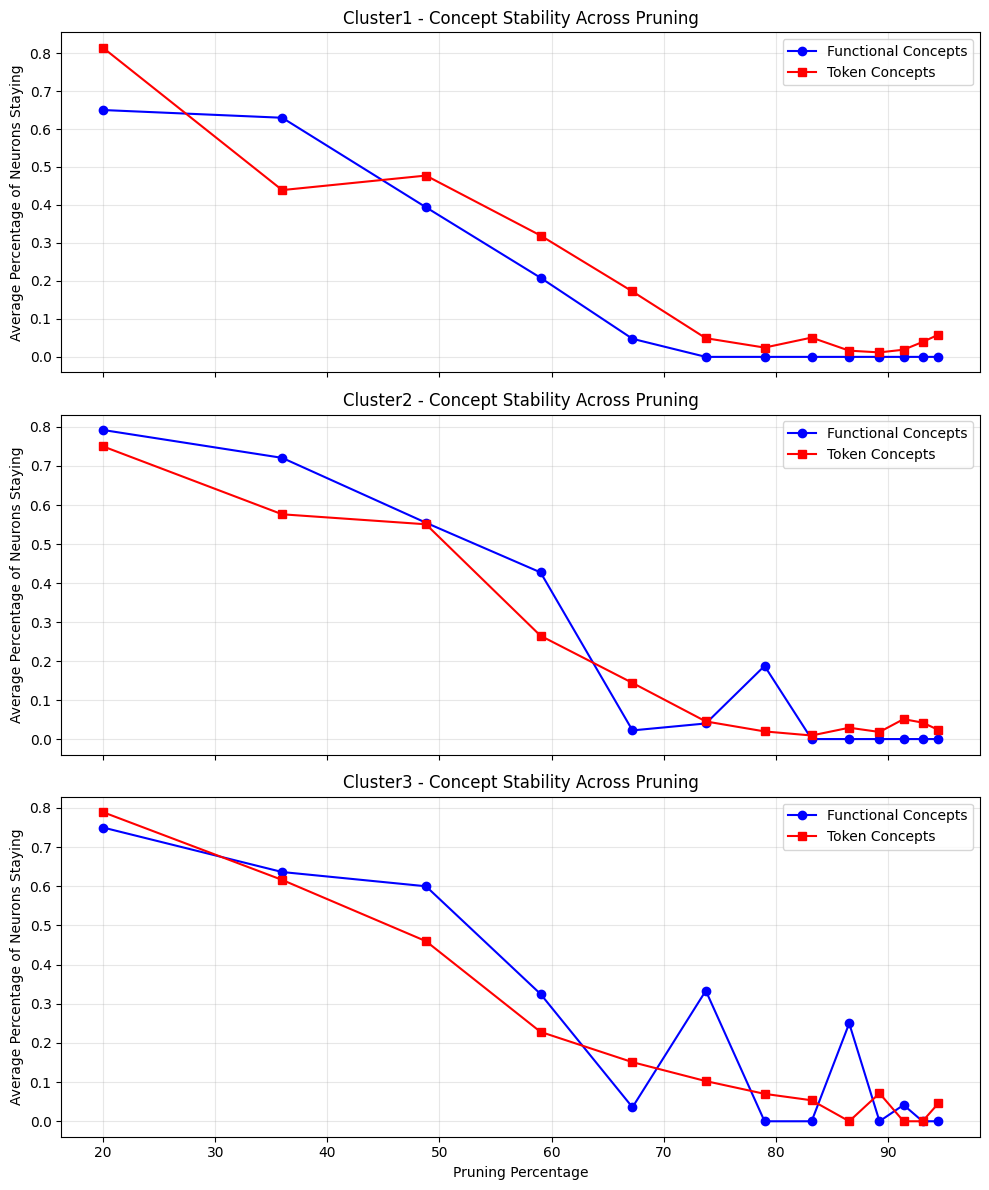

In [194]:
def visualize_concept_stability(graph):
    import matplotlib.pyplot as plt
    import numpy as np
    

    all_prune_iters = set()
    for cluster in graph:
        all_prune_iters.update(graph[cluster].keys())
  
    clusters = sorted(graph.keys())
    fig, axes = plt.subplots(len(clusters), 1, figsize=(10, 4*len(clusters)), sharex=True)
    
    if len(clusters) == 1:
        axes = [axes]  # Make it iterable if there's only one cluster
    
    for i, cluster in enumerate(clusters):
        ax = axes[i]
        

        x_values = []
        functional_values = []
        token_values = []
        
        for pi in prune_percents:
            if pi in graph[cluster]:
                x_values.append(float(pi.replace('% Prune', '')))
                functional_values.append(graph[cluster][pi].get('functional', 0))
                token_values.append(graph[cluster][pi].get('token', 0))
        
        # Plot
        ax.plot(x_values, functional_values, 'b-o', label='Functional Concepts')
        ax.plot(x_values, token_values, 'r-s', label='Token Concepts')
        ax.set_title(f'{cluster} - Concept Stability Across Pruning')
        ax.set_ylabel('Average Percentage of Neurons Staying')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.xlabel('Pruning Percentage')
    plt.tight_layout()
    plt.show()
    

visualize_concept_stability(graph)

Cluster transitions

In [ ]:
prune_percents = get_all_pruned_iters(concepts)
def rate_of_neurons_staying_at_cluster(concepts):        
    consistency = collections.defaultdict(dict)
    for concept in concepts.keys():
            
        originally_active_neurons = getActiveNeurons(concepts[concept], '0.0% Prune')
        if not originally_active_neurons: continue
        orig_mask = mask(originally_active_neurons)
        for pi in prune_percents:
            if pi == '0.0% Prune': continue
            neurons_active_at_pi = getActiveNeurons(concepts[concept], pi)
            if not neurons_active_at_pi or len(neurons_active_at_pi)==0:
                movement[concept][pi] = 0
                continue 
            pruned_mask = mask(neurons_active_at_pi)
            consistency_freq = percent_of_neurons_thatStayed_in_same_cluster(orig_mask, pruned_mask)
            
            consistency[concept][pi] = percent_of_neurons_thatStayed_in_same_cluster(orig_mask, pruned_mask)
    return consistency


0.0_Pruning_Iter
19.987_Pruning_Iter
35.97_Pruning_Iter
48.796_Pruning_Iter
59.017_Pruning_Iter
67.22_Pruning_Iter
73.763_Pruning_Iter
79.004_Pruning_Iter
83.203_Pruning_Iter
86.556_Pruning_Iter
89.258_Pruning_Iter
91.406_Pruning_Iter
93.099_Pruning_Iter
94.499_Pruning_Iter


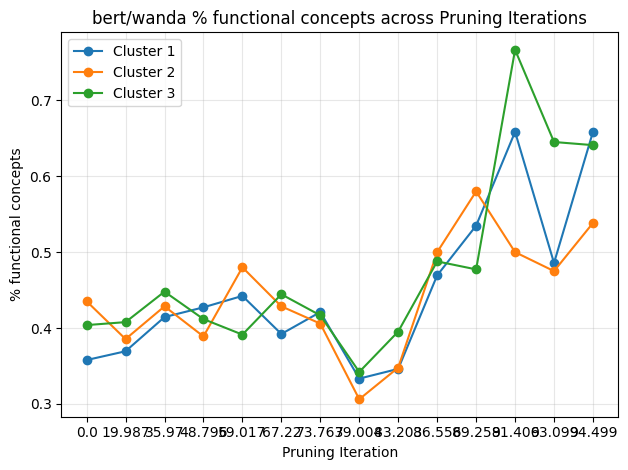

0.0_Pruning_Iter
19.971_Pruning_Iter
35.986_Pruning_Iter
48.779_Pruning_Iter
59.033_Pruning_Iter
67.188_Pruning_Iter
73.779_Pruning_Iter
79.004_Pruning_Iter
83.203_Pruning_Iter
86.572_Pruning_Iter
89.258_Pruning_Iter
91.406_Pruning_Iter
93.115_Pruning_Iter
94.482_Pruning_Iter


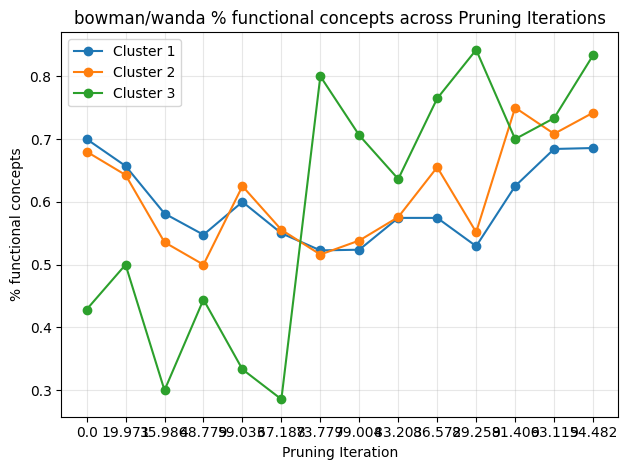

0.0_Pruning_Iter
20.0_Pruning_Iter
36.0_Pruning_Iter
48.8_Pruning_Iter
59.04_Pruning_Iter
67.232_Pruning_Iter
73.786_Pruning_Iter
79.028_Pruning_Iter
83.223_Pruning_Iter
86.578_Pruning_Iter
89.263_Pruning_Iter
91.41_Pruning_Iter
93.128_Pruning_Iter
94.502_Pruning_Iter


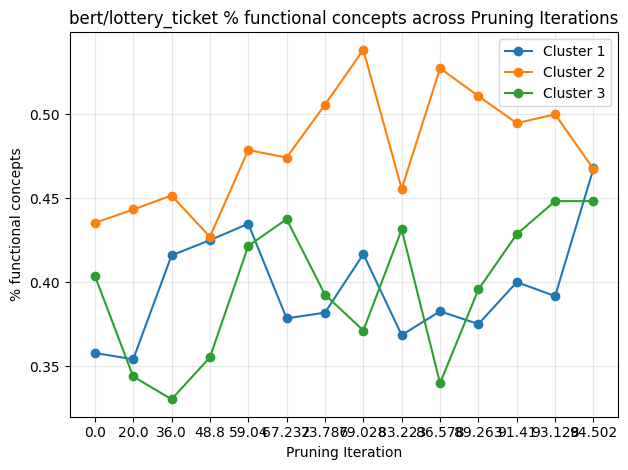

0.0_Pruning_Iter
20.0_Pruning_Iter
36.0_Pruning_Iter
48.8_Pruning_Iter
59.04_Pruning_Iter
67.232_Pruning_Iter
73.786_Pruning_Iter
79.028_Pruning_Iter
83.223_Pruning_Iter
86.578_Pruning_Iter
89.263_Pruning_Iter
91.41_Pruning_Iter
93.128_Pruning_Iter
94.502_Pruning_Iter


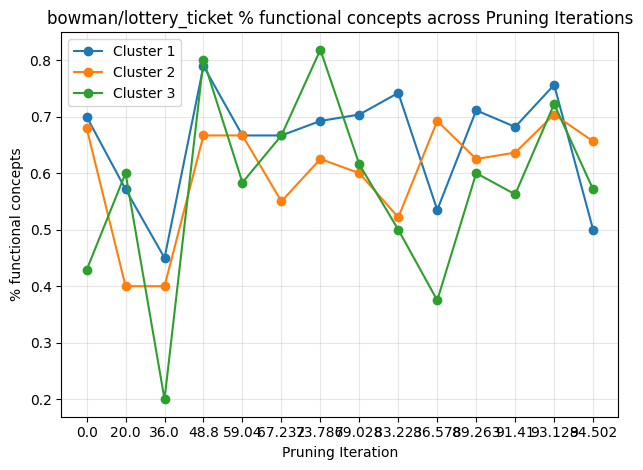

0.0_P


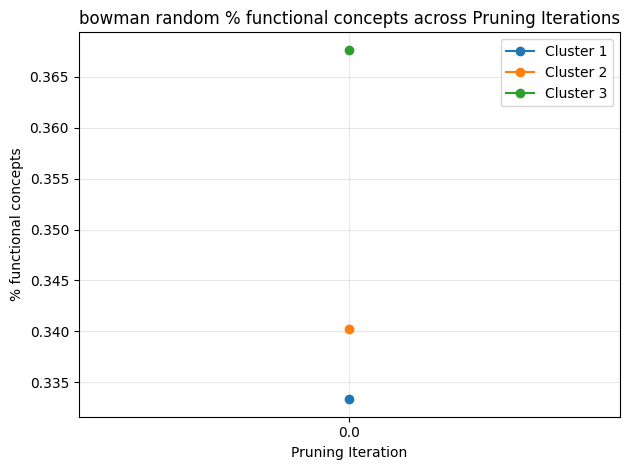

In [64]:

root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp"
f_c= set(["at", "in", "is", "there", "on", "to", "are", "for", "has", "not", "their" ,"is", "while", "and", "by", "with", "from", "are", "one", "no", "another", "this", "these", "that", "those", "my", "our", "your", "his", "her", "its", "their", "some", "any", "every", "other", "many", "more", "most", "enough", "few", "less", "much", "either", "neither", "several", "all", "both", "each", "one", "two", "three", "four", "first", "second", "third" ,"last", "can", "have", "be", "do", "could", "has", "am", "does", "will", "had", "is", "did", "would", "having", "are", "done", "shall", "was", "doing", "should", "were", "may", "been", "might", "being", "must", "but", "or", "yet", "nor", "for", "so", "before", "once", "since", "until", "when", "while", "as", "like",  "although", "though", "whereas", "while", "except", "because", "since", "if", "where", "when", "why", "whom", "whose", "which", "what", "how"])
def get_unique_concpets_per_cluster(p_i, cluster):
    cps=set()
    r=pd.read_csv(os.path.join(root, f"{p_i}",f'Cluster{cluster}IOUS1024N.csv'))
    for row in r.iterrows():
        row = row[1]
        form = row.best_name
        cps.update(set(get_indiv_concepts(form)))
    return len(cps) 
def get_concepts_per_cluster(root):
    concepts = collections.defaultdict(lambda : collections.defaultdict(set))
    
    for pruning_iter in os.listdir(root):
        if '.ipynb' in pruning_iter: continue
        pruned_percent = pruning_iter[:pruning_iter.index("_")]
        #for each cluster
        for cluster in os.listdir(os.path.join(root, pruning_iter)):
            if cluster == 'result.csv' or '.ipy' in cluster: continue
  
            cluster_num = cluster[7]
            for row in pd.read_csv(os.path.join(root, pruning_iter, cluster)).iterrows(): #fix this
                row = row[1]
                formula = row.best_name
                formula = get_indiv_concepts(formula)
                concepts[pruning_iter][cluster_num].update(formula)
    return concepts
def functional_concept_count(root):
    all_c = get_concepts_per_cluster(root)
    
    f_ccount=collections.defaultdict(lambda : collections.defaultdict(int))
    for p_i in all_c:
        for clus in all_c[p_i]:
            ct = 0
            for c in all_c[p_i][clus]:
                if ':tag:' in c or ':overlap:' in c:
                    ct+=1
                    continue
                for cc in f_c:
                    sc = f":tok:{cc}"
                    hyp_sc = "hyp"+sc
                    pre_sc = "pre"+sc
                    if hyp_sc in c or pre_sc in c:
                        ct += 1
            uq = get_unique_concpets_per_cluster(p_i, clus)
            f_ccount[p_i][int(clus)] = ct/uq
    return f_ccount


import matplotlib.pyplot as plt
import numpy as np
import collections

def graph_func_concepts(graph,title):
    # Define a graph to hold the IOU values by cluster
    cluster_data = collections.defaultdict(list)

    # Get the pruning iterations (x-values)
    prune_keys = sorted(graph.keys())  # Sorting pruning iterations
    
    # Collect IOU values for each cluster across pruning iterations
    for prune_key in prune_keys:
        print(prune_key)
        prune_data = graph[prune_key]
        
        # For each cluster, get the corresponding IOU value or NaN if not present
        for cluster in sorted(prune_data.keys()):
            # Append the IOU value to the respective cluster's list
            cluster_data[cluster].append(prune_data.get(cluster, np.nan))
    
    # Plot the IOU values for each cluster (separate lines)
    for cluster, y_values in cluster_data.items():
        plt.plot([prune_key[:prune_key.index("_")] for prune_key in prune_keys], y_values, marker='o', label=f"Cluster {cluster}")
        
    
    # Customize the plot
    plt.xlabel('Pruning Iteration')
    plt.ylabel('% functional concepts')
    plt.title(f'{title} % functional concepts across Pruning Iterations')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()

title = 'bert/wanda'
root="bert/wanda/RunBERTToVerifyFormulaMaskOveralpComp/Expls"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)


title = 'bowman/wanda'
root="bowman/wanda/RunBowmanWandaReformatted/Expls"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)


title = 'bert/lottery_ticket'
root="bert/lottery_ticket/RunBERT_LTHFIXED/Expls/"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)


title = 'bowman/lottery_ticket'
root="bowman/lottery_ticket/RunFIXEDLTH/Expls"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)

title = 'bowman random'
root = "random/bowman_new_weightsforfixedlth/expls"
f_ccount = functional_concept_count(root)
graph_func_concepts(f_ccount, title)

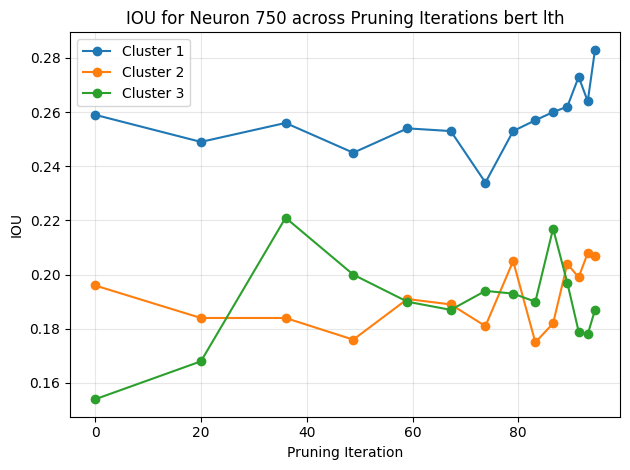

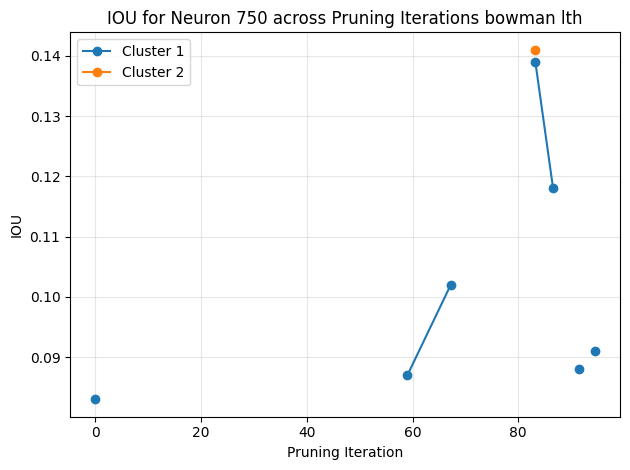

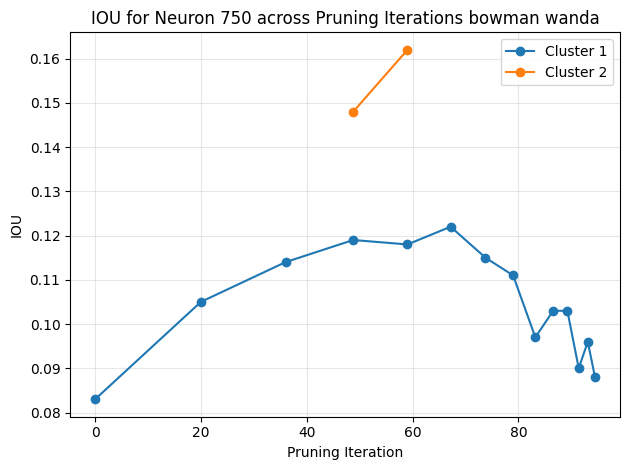

FileNotFoundError: [Errno 2] No such file or directory: 'bert/wanda/RunBERT/Expls/'

In [59]:
                
def get_ious(root):
    ious = collections.defaultdict(lambda : collections.defaultdict(lambda : collections.defaultdict(list)))
    #for each pruning iter
    for pruning_iter in os.listdir(root):
        if '.ipynb' in pruning_iter: continue
        pruned_percent = pruning_iter[:pruning_iter.index("_")]
        #for each cluster
        for cluster in os.listdir(os.path.join(root, pruning_iter)):
            if cluster == 'result.csv' or '.ipy' in cluster: continue
  
            cluster_num = cluster[7]
            for row in pd.read_csv(os.path.join(root, pruning_iter, cluster)).iterrows(): #fix this
                row = row[1]
                neuron, iou = row.unit ,float("{:.3f}".format(row.best_iou))
                ious[float(pruning_iter[:pruning_iter.index("_")])][neuron][cluster_num]=iou
    return ious

import collections
import matplotlib.pyplot as plt
def graph_change_iou(neuron,title, ious):
    # Dictionary to store IOU values by pruning iteration
    graph = collections.defaultdict(lambda: {})
    
    # Collect IOU values for the specified neuron at each pruning iteration
    for prune_key, prune_data in ious.items():
        if neuron in prune_data:
            # For each cluster in the current pruning iteration, store its IOU
            for cluster, iou in prune_data[neuron].items():
                graph[cluster][prune_key] = iou  # Store the IOU for this cluster and prune iteration
    
    # Get the pruning iterations (x-values)
    x_values = sorted(ious.keys())  # Sorting to ensure correct order of pruning iterations
    
    # Plotting the IOU values for each cluster (separate lines)
    for cluster, cluster_data in graph.items():
        y_values = []
        for prune_key in x_values:
            # If the cluster doesn't exist for this pruning iteration, append NaN
            y_values.append(cluster_data.get(prune_key, np.nan))
        
        # Plot the line for the current cluster
        plt.plot(x_values, y_values, marker='o', label=f"Cluster {cluster}")
    
    # Customize the plot
    plt.xlabel('Pruning Iteration')
    plt.ylabel('IOU')
    plt.title(f'IOU for Neuron {neuron} across Pruning Iterations {title}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.legend()
    plt.show()
root="bert/lottery_ticket/RunBERT_LTHFIXED/Expls/"
ious=get_ious(root)
title='bert lth'

neuron=750
graph_change_iou(neuron, title, ious)

root="bowman/lottery_ticket/RunFIXEDLTH/Expls"
ious=get_ious(root)
title='bowman lth'
graph_change_iou(neuron, title, ious)

root="bowman/wanda/RunBowmanWandaReformatted/Expls"
ious=get_ious(root)
title='bowman wanda'
graph_change_iou(neuron, title, ious)

root="bert/wanda/RunBERT/Expls/"
ious=get_ious(root)
title='bert wanda'
graph_change_iou(neuron, title, ious)

In [28]:
num = {'Cluster1': 0, 'Cluster2': 0, 'Cluster3': 0}
clus='Cluster1'
concept= "NOT hyp:tok:sleeping"
for perc, order in concepts[concept].items():
    all_active_neurons = order[clus] 
    num[clus] += len(all_active_neurons)
print(f"For concept {concept} {clus} on average {num[clus]/len(concepts[concept])}")
find_concept_details("NOT hyp:tok:sleeping")

For concept NOT hyp:tok:sleeping Cluster1 on average 16.142857142857142
In original at 
	Cluster 1: ['Neuron 86: IOU:0.243', 'Neuron 471: IOU:0.253', 'Neuron 1016: IOU:0.262', 'Neuron 212: IOU:0.25', 'Neuron 720: IOU:0.252', 'Neuron 981: IOU:0.236', 'Neuron 43: IOU:0.235', 'Neuron 951: IOU:0.23', 'Neuron 140: IOU:0.247', 'Neuron 47: IOU:0.254', 'Neuron 549: IOU:0.25', 'Neuron 135: IOU:0.249', 'Neuron 70: IOU:0.266', 'Neuron 420: IOU:0.252', 'Neuron 568: IOU:0.255', 'Neuron 197: IOU:0.227', 'Neuron 470: IOU:0.26', 'Neuron 824: IOU:0.259', 'Neuron 572: IOU:0.263', 'Neuron 183: IOU:0.249', 'Neuron 215: IOU:0.232']
	Cluster 2: ['Neuron 733: IOU:0.225', 'Neuron 758: IOU:0.239']
	Cluster 3: []
At 20.0% Prune% at 
	Cluster 1: ['Neuron 64: IOU:0.254', 'Neuron 935: IOU:0.243', 'Neuron 212: IOU:0.249', 'Neuron 273: IOU:0.261', 'Neuron 720: IOU:0.254', 'Neuron 1013: IOU:0.238', 'Neuron 43: IOU:0.25', 'Neuron 684: IOU:0.259', 'Neuron 721: IOU:0.256', 'Neuron 824: IOU:0.241', 'Neuron 183: IOU:0.245

In [4]:
num={}
for concept in concepts:
    clus='Cluster3'
    cts=0
    for perc, order in concepts[concept].items():
        num_active_neurs = 0
        all_active_neurons = order[clus] 
        cts += len(all_active_neurons)
    num[concept]=cts
    #print("for ", concept, " there are ", num[concept], " counts")
sum(num.values())/len(num) 

3.5504201680672267

In [5]:
def get_all_concepts(formula) -> list:
    concepts = []
    concps = re.findall(r'\b(?:NOT )?(?:pre:tok:|pre:tag:|hyp:tag:|hyp:tok:|oth:)\S*', formula)
    
    for i in range(len(concps)):
        try:
            end_idx = concps[i].index(')')
            concepts.append(concps[i][:end_idx])
        except:
            concepts.append(concps[i])
    return concepts

In [6]:
#iou hanges
import random
cluster='Cluster1'
concept=random.choice(list(concepts.keys()))
ious=collections.defaultdict(list)
for per, expl in concepts[concept].items():
    for neuriou in expl[cluster]:
        iou = neuriou.rfind(":")
        iou = neuriou[iou+1:]
        ious[per].append(iou)
myKeys = list(ious.keys())
myKeys.sort()

# Sorted Dictionary
sd = {i: ious[i] for i in myKeys}
print(concept)
sd

pre:tok:smiling


{}

In [7]:
concepts['NOT hyp:tok:not']

{'86.578% Prune': {'Cluster1': ['Neuron 250: IOU:0.244',
   'Neuron 950: IOU:0.254'],
  'Cluster2': [],
  'Cluster3': []},
 '93.128% Prune': {'Cluster1': ['Neuron 50: IOU:0.262',
   'Neuron 600: IOU:0.248',
   'Neuron 975: IOU:0.276'],
  'Cluster2': [],
  'Cluster3': []},
 '94.502% Prune': {'Cluster1': ['Neuron 50: IOU:0.254',
   'Neuron 175: IOU:0.245',
   'Neuron 250: IOU:0.249',
   'Neuron 950: IOU:0.269'],
  'Cluster2': [],
  'Cluster3': []},
 '91.41% Prune': {'Cluster1': ['Neuron 50: IOU:0.253',
   'Neuron 250: IOU:0.241',
   'Neuron 675: IOU:0.262'],
  'Cluster2': [],
  'Cluster3': []}}

In [8]:
sparsity['NOT hyp:tok:running']

NameError: name 'sparsity' is not defined

In [20]:
import matplotlib.pyplot as plt
import numpy as np
f_c= set(["at", "in", "is", "there", "on", "to", "are", "for", "has", "not", "their" ,"is", "while", "and", "by", "with", "from", "are", "one", "no", "another", "this", "these", "that", "those", "my", "our", "your", "his", "her", "its", "their", "some", "any", "every", "other", "many", "more", "most", "enough", "few", "less", "much", "either", "neither", "several", "all", "both", "each", "one", "two", "three", "four", "first", "second", "third" ,"last", "can", "have", "be", "do", "could", "has", "am", "does", "will", "had", "is", "did", "would", "having", "are", "done", "shall", "was", "doing", "should", "were", "may", "been", "might", "being", "must", "but", "or", "yet", "nor", "for", "so", "before", "once", "since", "until", "when", "while", "as", "like",  "although", "though", "whereas", "while", "except", "because", "since", "if", "where", "when", "why", "whom", "whose", "which", "what", "how"])

def check_sparsity(concepts):
    sparsity = {}
    for concept in concepts:
        if concept[concept.rfind(":")+1:] in f_c: continue
            
        #num of prune iters concept is defined at / ttal num of prune iters
        pruning_sparsity = len(concepts[concept]) / 14 #num prune iters concept is at 
        avg_cluster_sparsity=0 #num clusters concept is found at
        for percents, clusters in concepts[concept].items():
            active_clusters = 0
            for list_ in clusters:
                if len(concepts[concept][percents][list_]) > 0:
                    active_clusters += 1
            avg_cluster_sparsity  += (active_clusters/len(concepts[concept]))
        sparsity[concept] = {'Pruning sparsity': pruning_sparsity, "Cluster Sparsity":avg_cluster_sparsity }
    return sparsity

def get_prune_sparsity(sparsity):
    pruning_sparisty=[]
    lessthan5pruneiters=[]
    for concept in sparsity:
        if sparsity[concept]['Pruning sparsity'] < 0.6:
            lessthan5pruneiters.append(concept)
        pruning_sparisty.append(sparsity[concept]['Pruning sparsity'])
    return pruning_sparisty, lessthan5pruneiters

def get_cluster_sparsity(sparsity):
    cluster_sparsity=[]
    for concept in sparsity:
        cluster_sparsity.append(sparsity[concept]['Cluster Sparsity'])
    return cluster_sparsity

def get_avg_prune_sparsity(sparsity):
    pruning_sparisty,cluster_sparsity = 0,0
    for concept in sparsity:
        pruning_sparisty += sparsity[concept]['Pruning sparsity']
        cluster_sparsity += sparsity[concept]['Cluster Sparsity']
    print(pruning_sparisty/len(sparsity), cluster_sparsity/len(sparsity))

def box_plot(data,title):
    
    fig = plt.figure(figsize =(10, 7))
    plt.title(title)
    # Creating plot
    plt.boxplot(data)

    # show plot
    plt.show()
#Pruning sparsity: how many pruning iterations a concept ends up at (1 means all iterations 0 means none)
#Cluster sparsity: how many clusters within a pruning iter does a concept end up at (1 means all (for a single pruning iter), 0 means none)

In [175]:
gps, lessthan5pruneiters=get_prune_sparsity(sparsity)
ct=0
for i in lessthan5pruneiters:
    if i[i.rfind(":")+1:] in f_c or ':tag:' in i or ':overlap:' in i:
        ct+=1
ct, len(lessthan5pruneiters)

(58, 467)

0.4056809438317495 1.2147698576109707


TypeError: object of type 'NoneType' has no len()

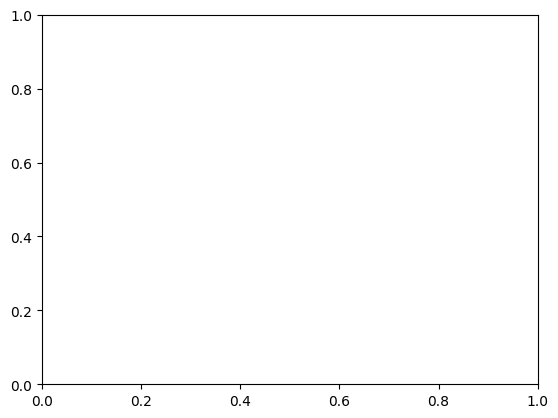

In [22]:
#wanda bert
root="../BERT/exp/bert/lottery_ticket/Run2Full/Expls" # "bowman/wanda/RunBowmanWandaReformatted/Expls" #"bowman/lottery_ticket/RunFIXEDLTH/Expls" #"bert/lottery_ticket/RunBERT_LTHFIXED/Expls/" #"bert/wanda/RunBERT/Expls/"  #bowman/lottery_ticket/RunFIXEDLTH/Expls
    
concepts=get_collected_concepts(root)

sparsity = check_sparsity(concepts)

#box_plot(get_cluster_sparsity(sparsity))
plt.hist(get_avg_prune_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 300, 50)
plt.yticks(y_ticks)
plt.title("bert wanda pruning sparsity")
plt.xlabel("Pruning sparsity bert wanda")
plt.ylabel("Number of concepts")
plt.show()

plt.hist(get_cluster_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 700, 50)
plt.yticks(y_ticks)
plt.title("bert wanda cluster sparsity")
plt.xlabel("cluster sparsity bert wanda")
plt.ylabel("Number of concepts")
plt.show()

0.317827130852345 1.1386390958869956
0.317827130852345 1.1386390958869956


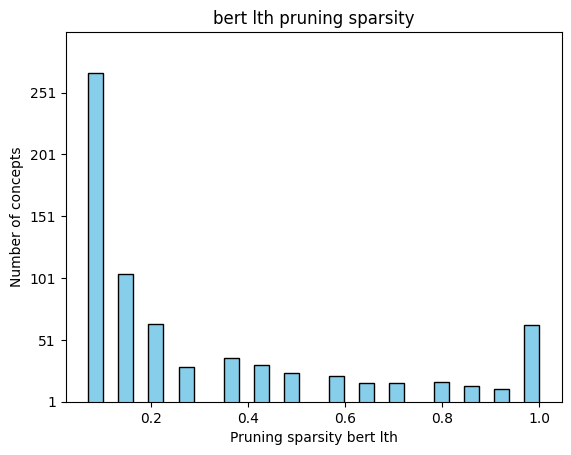

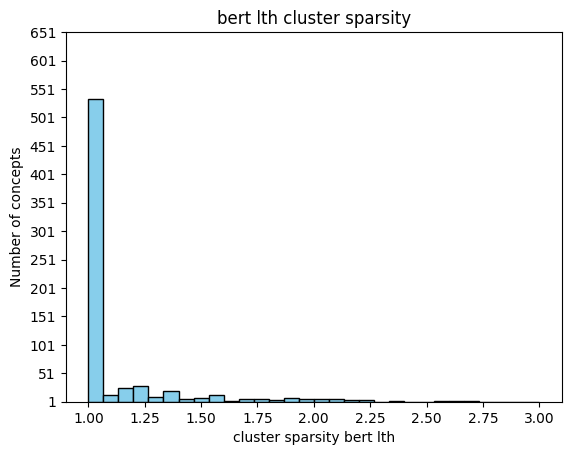

In [97]:
#lt bert
root="bert/lottery_ticket/RunBERT_LTHFIXED/Expls/" 
concepts=get_collected_concepts(root)

sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
#box_plot(get_cluster_sparsity(sparsity))
plt.hist(get_prune_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 300, 50)
plt.yticks(y_ticks)
plt.title("bert lth pruning sparsity")
plt.xlabel("Pruning sparsity bert lth")
plt.ylabel("Number of concepts")
plt.show()

plt.hist(get_cluster_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 700, 50)
plt.yticks(y_ticks)
plt.title("bert lth cluster sparsity")
plt.xlabel("cluster sparsity bert lth")
plt.ylabel("Number of concepts")
plt.show()

0.20665212649945422 1.0859922202479453
0.20665212649945422 1.0859922202479453


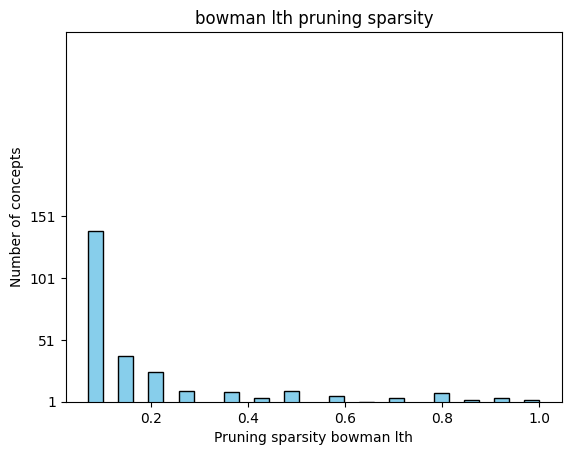

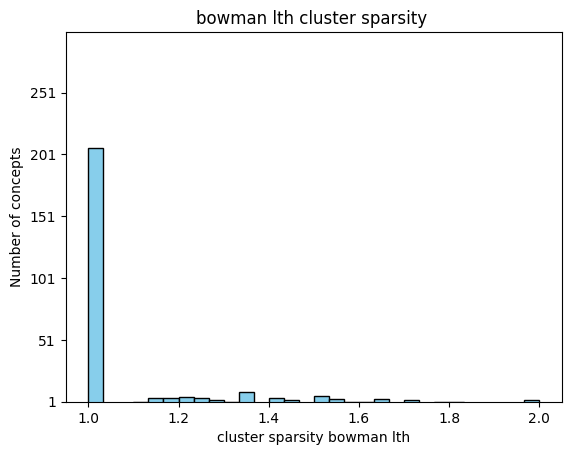

In [98]:
#lt bowman
root= "bowman/lottery_ticket/RunFIXEDLTH/Expls" 
concepts=get_collected_concepts(root)

sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
#box_plot(get_cluster_sparsity(sparsity))
plt.hist(get_prune_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 200, 50)
plt.yticks(y_ticks)
plt.title("bowman lth pruning sparsity")
plt.xlabel("Pruning sparsity bowman lth")
plt.ylabel("Number of concepts")
plt.show()

plt.hist(get_cluster_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 300, 50)
plt.yticks(y_ticks)
plt.title("bowman lth cluster sparsity ")
plt.xlabel("cluster sparsity bowman lth")
plt.ylabel("Number of concepts")
plt.show()

0.22582228767795756 1.1021398990471158


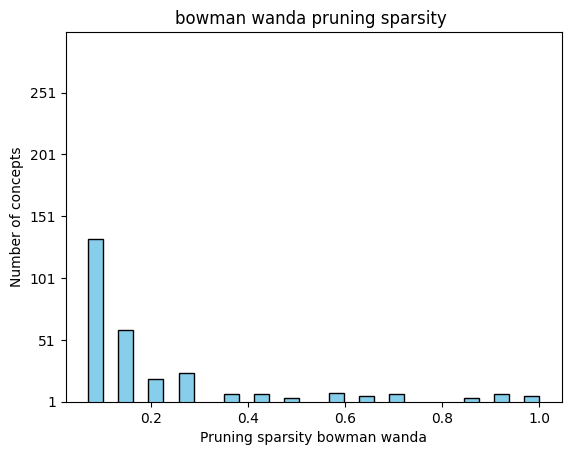

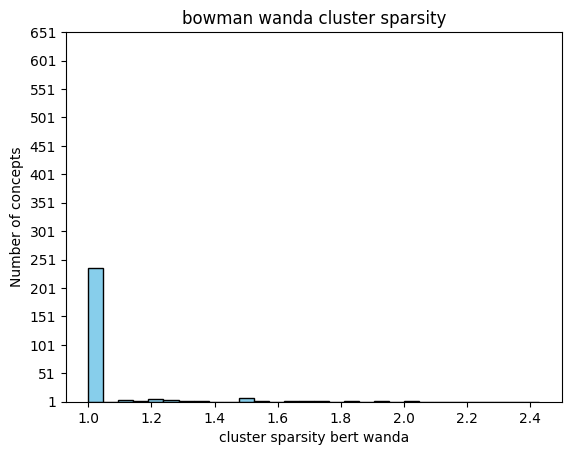

In [99]:
#wanda bowman
root="bowman/wanda/RunBowmanWandaReformatted/Expls" 
concepts=get_collected_concepts(root)

sparsity = check_sparsity(concepts)
get_avg_prune_sparsity(sparsity)
#box_plot(get_cluster_sparsity(sparsity))
plt.hist(get_prune_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 300, 50)
plt.yticks(y_ticks)
plt.title("bowman wanda pruning sparsity ")
plt.xlabel("Pruning sparsity bowman wanda")
plt.ylabel("Number of concepts")
plt.show()

plt.hist(get_cluster_sparsity(sparsity), bins=30, color='skyblue', edgecolor='black')
plt.ylim(1.0, 300)  # Set y-axis limits to match box plot
y_ticks = np.arange(1.0, 700, 50)
plt.yticks(y_ticks)
plt.title("bowman wanda cluster sparsity")
plt.xlabel("cluster sparsity bert wanda")
plt.ylabel("Number of concepts")
plt.show()

In [ ]:
get_cluster_sparsity(sparsity)